# **EXPLORING JOB DISSATISFACTION IN THE UK USING REDDIT DATA (2024 Dataset)**

## **AN NLP-BASED THEMATIC AND SENTIMENT ANALYSIS**


### **Student Name**: Awopetu Rasheed Oluwadamilare

### **Student Number**: 202432121

### **Library Installation**

In [2]:
pip install praw pandas tqdm python-dotenv emoji vaderSentiment textblob wordcloud pyLDAvis gensim bertopic

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 189.3/189.3 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 40.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 80.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 41.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 11.9 MB/s eta 0:00:00


In [3]:
pip install spacy

In [4]:
pip install tf-keras

### **Import the necessary libraries**

In [5]:
import pandas as pd
import os, time, json
import praw
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import re, emoji, nltk, spacy
import torch
import pyLDAvis
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)


from gensim.corpora.dictionary import Dictionary
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from umap.umap_ import UMAP
from hdbscan import HDBSCAN
from dotenv import load_dotenv
from datetime import datetime, timedelta
from tqdm import tqdm
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from textblob import TextBlob
from wordcloud import WordCloud
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.naive_bayes import MultinomialNB
from sklearn.utils import resample
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout
from nltk.corpus import stopwords
from sklearn.utils.class_weight import compute_class_weight
from sklearn.svm import LinearSVC
from transformers import (AutoTokenizer, AutoModelForSequenceClassification, DataCollatorWithPadding, Trainer, TrainingArguments)
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from gensim.models import CoherenceModel
from gensim.corpora import Dictionary
from gensim.models.ldamodel import LdaModel
from datetime import datetime, timedelta
import time
import pandas as pd
from tqdm import tqdm
from prawcore.exceptions import TooManyRequests
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    f1_score,
    classification_report,
    confusion_matrix
)

/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.


### **Loading Environment Variable from .env File**

##### To keep Reddit API credentials secure, we store them in a `.env` file instead of hardcoding into the script. So anytime we need them we can easily pass them to the reddit API easily

In [ ]:
environment_variable = load_dotenv()
if environment_variable:
    print("Environment variables loaded successfully.")
else:
    print("Failed to load environment variables. Please Upload .env file")

Environment variables loaded successfully.


### **Loading Dataset & Data Collection**

We will collects Reddit posts and comments related to **job dissatisfaction & Satisfaction in the UK**.  
- Subreddits: `ukjobs`, `AskUK`, `CasualUK`, `unitedkingdom`, `britishproblems`, `antiwork`, `antiwork`, `WorkReform`, `careerguidance`, `AskHR`, `britishproblems`,.  
- Queries: dissatisfaction terms (e.g., *"hate my job"*, *"toxic workplace"*) and satisfaction terms (e.g., *"love my job"*).  
- UK filter ensures posts are from UK-focused subs or mention UK places.  
- Data Period Lenght: **January 2024 to December 2024**  
- Output: two CSV files (`reddit_posts_uk_jobs.csv`, `reddit_comments_uk_jobs.csv`).

##### Firstly, let create a subreddit list that we intend to use.

In [ ]:
SUBREDDITS = [
    "UKJobs", "AskUK", "CasualUK", "unitedkingdom", "antiwork", "WorkReform",
    "careerguidance", "AskHR", "britishproblems", "recruitinghell", "WorkReformUK"
]

print(f"List of subreddits: {(SUBREDDITS)}")

List of subreddits: ['UKJobs', 'AskUK', 'CasualUK', 'unitedkingdom', 'antiwork', 'WorkReform', 'careerguidance', 'AskHR', 'britishproblems', 'recruitinghell', 'WorkReformUK']


##### **Query Terms**

Two sets of keyword queries were defined to guide Reddit searches:  

- **Job Dissatisfaction** → phrases like *"hate my job"*, *"toxic workplace"*, *"low pay"*, *"burnout"*, *"bad boss"*, and *"bullying at work"*.  
- **Job Satisfaction** → phrases like *"love my job"*, *"happy at work"*, *"good boss"*, *"work life balance"*, and *"fair pay"*.  

These terms ensure we capture a broad range of posts expressing both negative and positive experiences with work in the UK.

In [ ]:
DISSATISFACTION_TERMS = [
    "job dissatisfaction", "hate my job", "toxic workplace", "burnout", "overworked",
    "bad boss", "micromanagement", "low pay", "underpaid", "quit my job", "resign",
    "stress at work", "bullying at work", "zero hours", "unhappy at work", "stressful job", "poor management", "burnt out", "miserable at work",
    "dead-end job", "exploited at work", "no work-life balance", "hate going to work", "rejection", "really bad", "unreasonable", "management cuts benefits"
]

print(f"List of Dissatisfaction terms: {(DISSATISFACTION_TERMS)}")

List of Dissatisfaction terms: ['job dissatisfaction', 'hate my job', 'toxic workplace', 'burnout', 'overworked', 'bad boss', 'micromanagement', 'low pay', 'underpaid', 'quit my job', 'resign', 'stress at work', 'bullying at work', 'zero hours', 'unhappy at work', 'stressful job', 'poor management', 'burnt out', 'miserable at work', 'dead-end job', 'exploited at work', 'no work-life balance', 'hate going to work', 'rejection', 'really bad', 'unreasonable', 'management cuts benefits']


In [ ]:
SATISFACTION_TERMS = [
    "love my job", "happy at work", "good boss", "great team", "work life balance",
    "supportive manager", "flexible working", "fair pay"
]
print(f"List of Satisfaction terms: {(SATISFACTION_TERMS)}")

List of Satisfaction terms: ['love my job', 'happy at work', 'good boss', 'great team', 'work life balance', 'supportive manager', 'flexible working', 'fair pay']


##### A regex filter **(`UK_REGEX`)** was applied to retain only posts from UK-focused subreddits or those mentioning UK locations (e.g., London, Manchester, Scotland).

In [ ]:
UK_REGEX = re.compile(r"\b(UK|United Kingdom|England|Scotland|Wales|Northern Ireland|London|Manchester|Birmingham|Leeds|Glasgow|Bristol|Liverpool)\b", re.IGNORECASE)

##### **Reddit API Authentication** -> Access to Reddit data was established using the **PRAW (Python Reddit API Wrapper)** library.  Authentication requires three environment variables loaded from the `.env` file:

In [ ]:
reddit = praw.Reddit(client_id=os.getenv("CLIENT_ID"), client_secret=os.getenv("CLIENT_SECRET"), user_agent=os.getenv("USER_AGENT"), check_for_async=False, )

##### A helper function was used to retain only posts from UK-focused subreddits or those mentioning UK locations.  

In [ ]:
def is_uk_related(text: str, subreddit: str) -> bool:
    if subreddit.lower() in {"ukjobs", "askuk", "casualuk", "unitedkingdom", "britishproblems"}:
        return True
    return bool(UK_REGEX.search(text or ""))

##### A custom function was used to search target subreddits with defined queries, filter by UK relevance and time window, and return labelled posts with top-level comments for analysis.  

#### **Push shift documentation** -> https://github.com/pushshift/api

In [ ]:
from datetime import datetime, timedelta
import time
import pandas as pd
from tqdm import tqdm
from prawcore.exceptions import TooManyRequests

def search_and_collect(queries, label):
    """
    Search posts for each query across target subreddits, INCLUDE metadata AND top comments.
    Only 2024 data. Handles Reddit 429 rate limiting.
    label = 'dissatisfaction' or 'satisfaction'
    """
    start_2024 = int(datetime(2024, 1, 1).timestamp())
    end_2024   = int(datetime(2024, 12, 31, 23, 59, 59).timestamp())

    rows_posts, rows_comments = [], []

    for sr in SUBREDDITS:
        sub = reddit.subreddit(sr)

        for q in queries:
            while True:
                try:
                    results = list(sub.search(q, sort="new", limit=500))
                    break
                except TooManyRequests as e:
                    retry_after = getattr(e, "sleep_time", None)
                    if retry_after is None:
                        retry_after = 60
                    print(f"[RATE LIMIT] Search hit 429. Sleeping {retry_after} seconds...")
                    time.sleep(retry_after)

            for s in tqdm(results, desc=f"{sr} | {q}"):

                # Only 2024 posts
                if not (start_2024 <= s.created_utc <= end_2024):
                    continue

                # UK filter
                blob = f"{s.title}\n{s.selftext or ''}"
                if not is_uk_related(blob, sr):
                    continue

                post_row = {
                    "id": s.id,
                    "subreddit": sr,
                    "created_utc": s.created_utc,
                    "created_iso": datetime.utcfromtimestamp(s.created_utc).isoformat(),
                    "author": str(s.author) if s.author else None,
                    "title": s.title,
                    "selftext": s.selftext,
                    "score": s.score,
                    "num_comments": s.num_comments,
                    "url": s.url,
                    "permalink": f"https://www.reddit.com{s.permalink}",
                    "query": q,
                    "label": label,
                    "source": "reddit_api",
                }
                rows_posts.append(post_row)

                try:
                    s.comment_sort = "top"
                    s.comments.replace_more(limit=0)

                    for c in s.comments[:25]:
                        rows_comments.append({
                            "post_id": s.id,
                            "comment_id": c.id,
                            "created_utc": c.created_utc,
                            "created_iso": datetime.utcfromtimestamp(c.created_utc).isoformat(),
                            "author": str(c.author) if c.author else None,
                            "body": c.body,
                            "score": c.score,
                            "permalink": f"https://www.reddit.com{c.permalink}",
                            "subreddit": sr,
                            "post_query": q,
                            "post_label": label,
                        })

                except TooManyRequests as e:
                    retry_after = getattr(e, "sleep_time", None)
                    if retry_after is None:
                        retry_after = 60
                    print(f"[RATE LIMIT] Comments hit 429. Sleeping {retry_after} seconds...")
                    time.sleep(retry_after)

                time.sleep(0.8)

            time.sleep(2)
        time.sleep(3)

    return pd.DataFrame(rows_posts), pd.DataFrame(rows_comments)


###### **Data Collection and Storage**
The script collects Reddit posts for both dissatisfaction and satisfaction queries, merges and de-duplicates results, and saves labelled posts and comments as CSV files for subsequent NLP, sentiment, and thematic analysis.  

In [ ]:
if __name__ == "__main__":
    posts_diss, comments_diss = search_and_collect(DISSATISFACTION_TERMS, "dissatisfaction")
    posts_sat,  comments_sat  = search_and_collect(SATISFACTION_TERMS, "satisfaction")

    posts = pd.concat([posts_diss, posts_sat], ignore_index=True)
    posts = posts.drop_duplicates(subset=["id"])
    comments = pd.concat([comments_diss, comments_sat], ignore_index=True)
    comments = comments.drop_duplicates(subset=["comment_id"])

    os.makedirs("data", exist_ok=True)
    posts.to_csv("data/reddit_posts_uk_jobs.csv", index=False)
    comments.to_csv("data/reddit_comments_uk_jobs.csv", index=False)

    print("Saved data/reddit_posts_uk_jobs.csv and data/reddit_comments_uk_jobs.csv")

UKJobs | job dissatisfaction: 100%|█████████████| 12/12 [00:05<00:00,  2.02it/s]
UKJobs | hate my job: 100%|███████████████████| 225/225 [00:34<00:00,  6.49it/s]
UKJobs | toxic workplace: 100%|█████████████████| 68/68 [00:37<00:00,  1.81it/s]
UKJobs | burnout: 100%|█████████████████████████| 84/84 [00:33<00:00,  2.55it/s]
UKJobs | overworked: 100%|██████████████████████| 73/73 [00:36<00:00,  2.01it/s]
UKJobs | bad boss: 100%|██████████████████████| 151/151 [01:04<00:00,  2.34it/s]
UKJobs | micromanagement: 100%|███████████████| 113/113 [00:47<00:00,  2.36it/s]
UKJobs | low pay: 100%|███████████████████████| 231/231 [01:37<00:00,  2.36it/s]
UKJobs | underpaid: 100%|█████████████████████| 229/229 [01:25<00:00,  2.67it/s]
UKJobs | quit my job: 100%|███████████████| 238/238 [00:00<00:00, 796048.13it/s]
UKJobs | resign: 100%|████████████████████████| 236/236 [00:57<00:00,  4.13it/s]
UKJobs | stress at work: 100%|███████████| 241/241 [00:00<00:00, 1210571.57it/s]
UKJobs | bullying at work: 1

Saved data/reddit_posts_uk_jobs.csv and data/reddit_comments_uk_jobs.csv


###### We are using pandas to load two CSV files. One with Reddit posts and another with comments from the UK jobs subreddit. We let pandas handle any tricky line breaks and skip over bad lines so nothing breaks while loading. In the end, we just print out the number of rows and columns to get a quick feel for how big our datasets are.

In [ ]:
posts = pd.read_csv("data/reddit_posts_uk_jobs.csv", lineterminator='\n')
comments = pd.read_csv("data/reddit_comments_uk_jobs.csv", lineterminator='\n', on_bad_lines='skip')

print("Posts:", posts.shape)
print("Comments:", comments.shape)

Posts: (2473, 14)
Comments: (28675, 11)


### **CSV File combined**

###### Let **combined the 2 datset** together so we can be able to work with a single dataset

###### We’re adding a new column called source to both our datasets. We let the posts have the label "post" and the comments have the label "comment". This way, when we eventually combine or analyze everything together, we’ll know exactly which entries came from posts and which came from comments.

In [ ]:
posts["source"] = "post"
comments["source"] = "comment"

###### For the posts, we fill in any missing titles or selftexts with empty strings, then combine them into one column called text_raw so each post has a single block of text. For the comments, we fill any missing body text with an empty string and store it in text_raw as well.

In [ ]:
posts["title"] = posts["title"].fillna("")
posts["selftext"] = posts["selftext"].fillna("")
posts["text_raw"] = (posts["title"] + " " + posts["selftext"]).str.strip()

comments["body"] = comments["body"].fillna("")
comments["text_raw"] = comments["body"]

###### Streamlining our data by keeping only the most important columns. For the posts, we select useful fields like the post ID, subreddit, author, text, score, and a few others that we’ll need for analysis. For the comments, we first rename some columns like changing comment_id to id, post_query to query, and post_label to label so they match the posts dataset. Then, we keep the same set of columns as in the posts DataFrame. This makes both datasets consistent and ready to be combined or compared later on.

In [ ]:
# Columns to keep for posts
posts_small = posts[[
    "id","subreddit","created_utc","author","text_raw","score",
    "query","label","source","permalink"
]]

# Columns to keep for comments
comments_small = comments.rename(columns={
    "comment_id": "id",
    "post_query": "query",
    "post_label": "label"
})[[
    "id","subreddit","created_utc","author","text_raw","score",
    "query","label","source","permalink"
]]

###### We use pd.concat() to stack them together and set ignore_index=True so the index resets automatically. After merging, we print out the new dataset’s shape to see how big it is, and then display the first few rows with dataset.head() to make sure everything looks right.

In [ ]:
dataset = pd.concat([posts_small, comments_small], ignore_index=True)
print("Combined dataset shape:", dataset.shape)
dataset.head()

Combined dataset shape: (31148, 10)


,id,subreddit,created_utc,author,text_raw,score,query,label,source,permalink
0,1hcho9i,UKJobs,1.733997e+09,Ok-Distance-5344,If you knew you were getting replaced next mon...,2,job dissatisfaction,dissatisfaction,post,https://www.reddit.com/r/UKJobs/comments/1hcho...
1,1fjpfib,UKJobs,1.726655e+09,Unusual_Addition3422,Unexpected negative feedback - should I resign...,13,job dissatisfaction,dissatisfaction,post,https://www.reddit.com/r/UKJobs/comments/1fjpf...
2,1f5sf4s,UKJobs,1.725125e+09,Single_Exercise_1035,"Need Advice, Poor Mental & Physical Health wor...",3,job dissatisfaction,dissatisfaction,post,https://www.reddit.com/r/UKJobs/comments/1f5sf...
3,1bhj1hg,UKJobs,1.710739e+09,Otherwise_Ad630,Struggling to get a fair salary I graduated f...,14,job dissatisfaction,dissatisfaction,post,https://www.reddit.com/r/UKJobs/comments/1bhj1...
4,1aydktg,UKJobs,1.708727e+09,cowgirlfr0mhell,Update: still being forced to work weekends fo...,56,job dissatisfaction,dissatisfaction,post,https://www.reddit.com/r/UKJobs/comments/1aydk...


##### Saving the combined dataset so we can use it in our sentiment analysis

In [ ]:
dataset.to_csv('2024_JOB_Dissatisfaction.csv', index=False)

#### **Loading Saved Dataset**

###### We’re importing our dataset from a CSV file and taking a quick look at the top few records to get familiar with the structure of the data before we dive into analysis.

In [ ]:
Dataset = pd.read_csv('2024_JOB_Dissatisfaction.csv')
Dataset.head()

,id,subreddit,created_utc,author,text_raw,score,query,label,source,permalink
0,1hcho9i,UKJobs,1.733997e+09,Ok-Distance-5344,If you knew you were getting replaced next mon...,2,job dissatisfaction,dissatisfaction,post,https://www.reddit.com/r/UKJobs/comments/1hcho...
1,1fjpfib,UKJobs,1.726655e+09,Unusual_Addition3422,Unexpected negative feedback - should I resign...,13,job dissatisfaction,dissatisfaction,post,https://www.reddit.com/r/UKJobs/comments/1fjpf...
2,1f5sf4s,UKJobs,1.725125e+09,Single_Exercise_1035,"Need Advice, Poor Mental & Physical Health wor...",3,job dissatisfaction,dissatisfaction,post,https://www.reddit.com/r/UKJobs/comments/1f5sf...
3,1bhj1hg,UKJobs,1.710739e+09,Otherwise_Ad630,Struggling to get a fair salary I graduated f...,14,job dissatisfaction,dissatisfaction,post,https://www.reddit.com/r/UKJobs/comments/1bhj1...
4,1aydktg,UKJobs,1.708727e+09,cowgirlfr0mhell,Update: still being forced to work weekends fo...,56,job dissatisfaction,dissatisfaction,post,https://www.reddit.com/r/UKJobs/comments/1aydk...


### **Data Exploration**

###### Let's examining and understanding our dataset before doing any analysis or modeling.

##### **Displaying basic info of the Dataset**

In [ ]:
print(Dataset.shape)

(31148, 10)


In [ ]:
print(Dataset.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31148 entries, 0 to 31147
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           31148 non-null  object 
 1   subreddit    31148 non-null  object 
 2   created_utc  31148 non-null  float64
 3   author       27248 non-null  object 
 4   text_raw     31148 non-null  object 
 5   score        31148 non-null  int64  
 6   query        31148 non-null  object 
 7   label        31148 non-null  object 
 8   source       31148 non-null  object 
 9   permalink    31148 non-null  object 
dtypes: float64(1), int64(1), object(8)
memory usage: 2.4+ MB
None


##### **Checking Missing Value**

In [ ]:
print(Dataset.isnull().sum())

id                0
subreddit         0
created_utc       0
author         3900
text_raw          0
score             0
query             0
label             0
source            0
permalink         0
dtype: int64


###### From the dataset we discover we only have NAN only in the author role and also we have 1 NAN is text_raw. all this will be cleaned during the Data Cleaning Process

##### **Checking for Duplicates**

In [ ]:
print(Dataset.duplicated(subset=['text_raw']).sum())

2729


###### We discovered that we have 2,729 Duplicates in our Dataset. We are going to remove all this duplicates during the data cleaning

###### Let check our `label` field that we go from the **Reddit API**  

In [ ]:
print(Dataset['label'].value_counts())

label
dissatisfaction    22918
satisfaction        8230
Name: count, dtype: int64


###### We clearly discovered that we have 22,918 data that is related to dissatisfaction and 8,230 data that relate to satisfaction.

/tmp/ipython-input-7856422.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='label', data=Dataset, palette=["red", "green"])


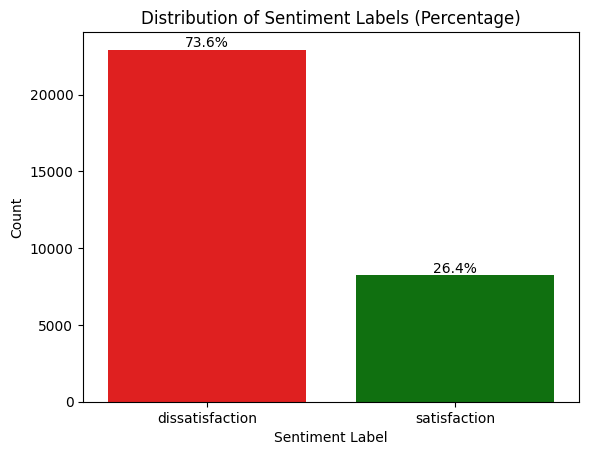

In [ ]:
ax = sns.countplot(x='label', data=Dataset, palette=["red", "green"])

total = len(Dataset)

for p in ax.patches:
    percentage = 100 * p.get_height() / total
    ax.annotate(f'{percentage:.1f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10, color='black')

plt.title('Distribution of Sentiment Labels (Percentage)')
plt.xlabel('Sentiment Label')
plt.ylabel('Count')
plt.show()

##### Let explore data based on Subreddit

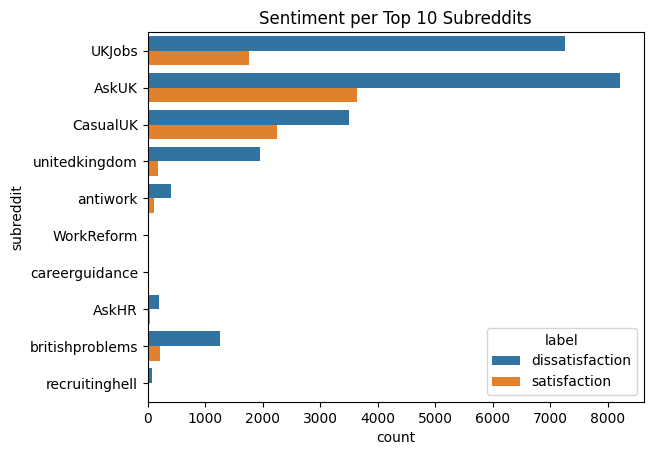

In [ ]:
top_subs = Dataset['subreddit'].value_counts().head(11).index
sns.countplot(y='subreddit', hue='label', data=Dataset[Dataset['subreddit'].isin(top_subs)])
plt.title('Sentiment per Top 10 Subreddits')
plt.show()

###### Let’s find the top subreddits, filter our dataset to include only them, and see how their sentiments compare

In [ ]:
top_subs = Dataset['subreddit'].value_counts().head(11).index
top_data = Dataset[Dataset['subreddit'].isin(top_subs)]
sentiment_table = pd.crosstab(top_data['subreddit'], top_data['label'])
display(sentiment_table)

label,dissatisfaction,satisfaction
subreddit,,
AskHR,203,42
AskUK,8218,3642
CasualUK,3506,2245
UKJobs,7252,1753
WorkReform,29,24
antiwork,406,116
britishproblems,1256,211
careerguidance,29,0
recruitinghell,69,27


###### Let’s find the top subreddits, filter our dataset to include only them, and see how their sentiments compare using the percentage

In [ ]:
top_subs = Dataset['subreddit'].value_counts().head(10).index
top_data = Dataset[Dataset['subreddit'].isin(top_subs)]
sentiment_percent = pd.crosstab(top_data['subreddit'], top_data['label'], normalize='index') * 100
sentiment_percent = sentiment_percent.round(1)
display(sentiment_percent)

label,dissatisfaction,satisfaction
subreddit,,
AskHR,82.9,17.1
AskUK,69.3,30.7
CasualUK,61.0,39.0
UKJobs,80.5,19.5
WorkReform,54.7,45.3
antiwork,77.8,22.2
britishproblems,85.6,14.4
careerguidance,100.0,0.0
recruitinghell,71.9,28.1


###### Let’s create word clouds to visualize what people talk about most comparing positive (satisfaction) and negative (dissatisfaction) words side by side

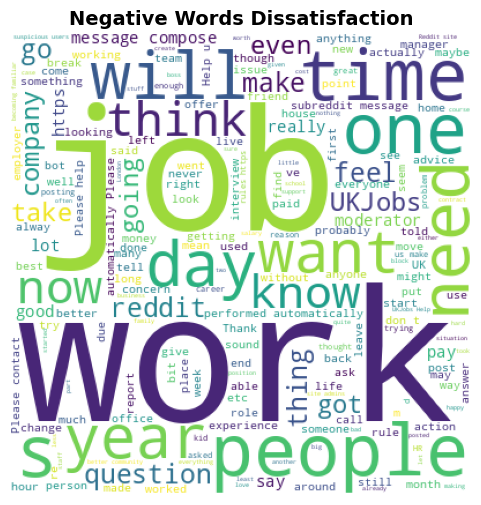

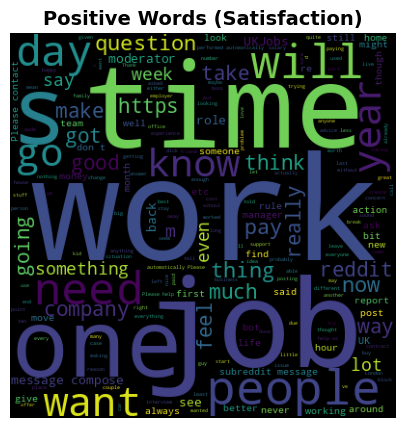

In [ ]:
pos_text = ' '.join(Dataset[Dataset['label']=='satisfaction']['text_raw'])
neg_text = ' '.join(Dataset.loc[Dataset['label'] == 'dissatisfaction', 'text_raw'].dropna().astype(str))

plt.figure(figsize=(6, 6))
plt.imshow(WordCloud(width=400, height=400, background_color='white').generate(neg_text))
plt.title('Negative Words Dissatisfaction', fontsize=14, fontweight='bold')
plt.axis('off')
plt.show()

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.imshow(WordCloud(width=400, height=400).generate(pos_text))
plt.title('Positive Words (Satisfaction)', fontsize=14, fontweight='bold')
plt.axis('off')

plt.show()

###### **Frequency of each unique based on Query**

Unique queries: ['job dissatisfaction' 'hate my job' 'toxic workplace' 'burnout'
 'overworked' 'bad boss' 'micromanagement' 'low pay' 'underpaid' 'resign'
 'bullying at work' 'zero hours' 'unhappy at work' 'poor management'
 'burnt out' 'miserable at work' 'dead-end job' 'exploited at work'
 'no work-life balance' 'unreasonable' 'quit my job' 'stress at work'
 'stressful job' 'rejection' 'management cuts benefits'
 'hate going to work' 'really bad' 'happy at work' 'good boss'
 'great team' 'flexible working' 'fair pay' 'love my job'
 'supportive manager' 'work life balance']


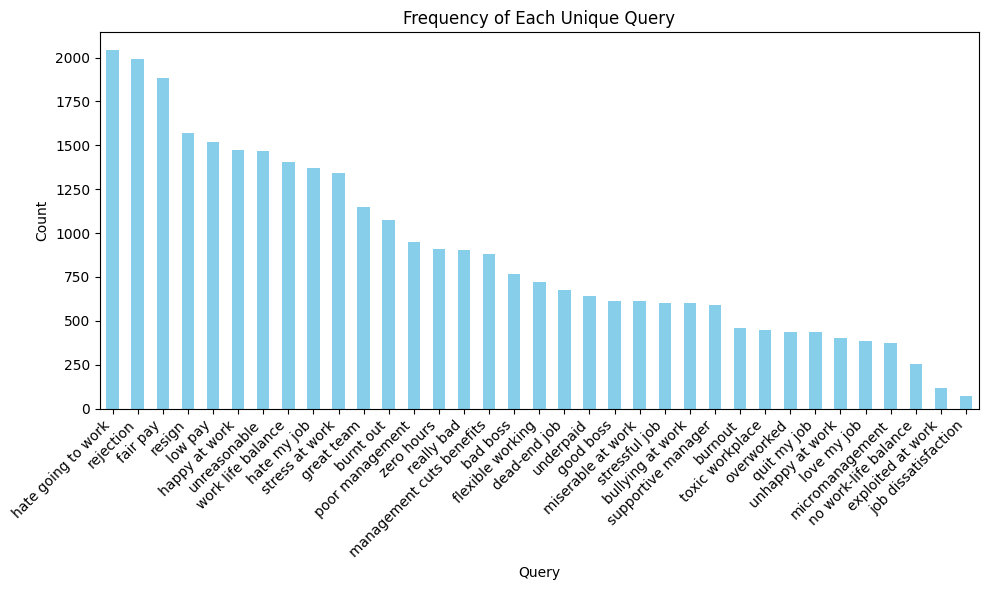

In [ ]:
query_counts = Dataset['query'].value_counts()

print("Unique queries:", Dataset['query'].unique())

plt.figure(figsize=(10, 6))
query_counts.plot(kind='bar', color='skyblue')
plt.title('Frequency of Each Unique Query')
plt.xlabel('Query')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

###### **Let display a chart based on the source**

Unique queries: ['post' 'comment']


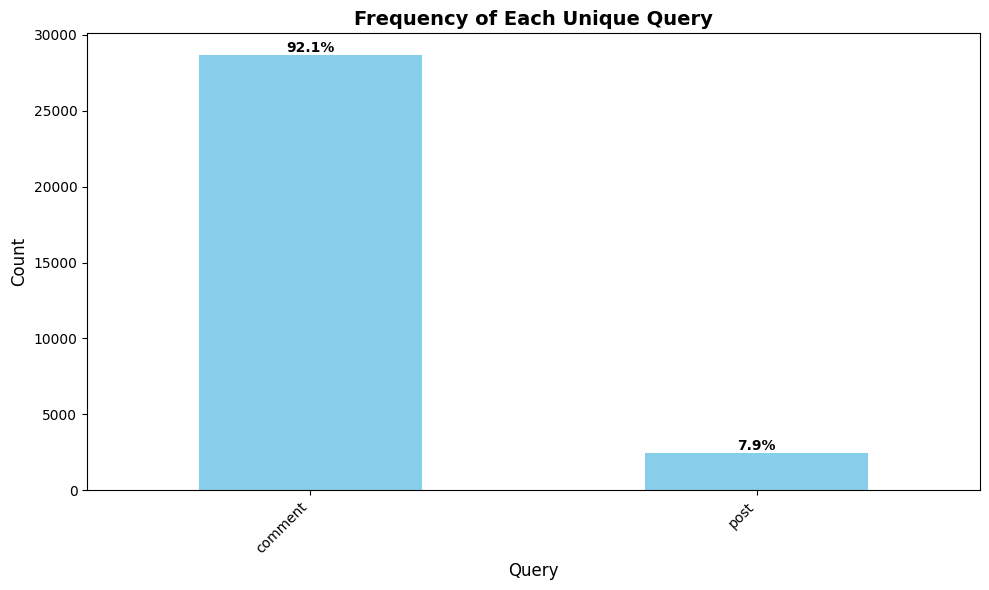

In [ ]:
query_counts = Dataset['source'].value_counts()

print("Unique queries:", Dataset['source'].unique())

total = query_counts.sum()

plt.figure(figsize=(10, 6))
ax = query_counts.plot(kind='bar', color='skyblue')

for i, count in enumerate(query_counts):
    percent = 100 * count / total
    ax.text(i, count + 0.5, f'{percent:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.title('Frequency of Each Unique Query', fontsize=14, fontweight='bold')
plt.xlabel('Query', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

### **Data Cleaning**

###### Removing the column with [Removed] and [Deleted] columns

In [ ]:
print("Row before cleaning:", len(Dataset))

Dataset = Dataset[~Dataset['text_raw'].isin(['[deleted]', '[removed]'])]
Dataset = Dataset[~Dataset['text_raw'].str.lower().str.strip().isin(['[deleted]', '[removed]'])]
Dataset = Dataset.reset_index(drop=True)

print("Remaining rows after cleaning:", len(Dataset))


Row before cleaning: 31148
Remaining rows after cleaning: 30296


###### Drop rows with missing or empty text

In [ ]:
print("Row before dropping missing/empty text:", len(Dataset))

Dataset = Dataset[Dataset['text_raw'].notnull() & (Dataset['text_raw'].str.strip() != '')]

print("Row After dropping missing/empty text:", len(Dataset))

Row before dropping missing/empty text: 30296
Row After dropping missing/empty text: 30296


###### **Let handle the NAN Value**

In [ ]:
print(Dataset.isnull().sum())

id                0
subreddit         0
created_utc       0
author         3048
text_raw          0
score             0
query             0
label             0
source            0
permalink         0
dtype: int64


###### We found 3,048 missing values in the *author* column. Since Reddit usernames are mostly anonymous and not useful for our training, we’ll simply drop this column.

In [ ]:
Dataset = Dataset.drop('author', axis=1)

In [ ]:
print(Dataset.isnull().sum())

id             0
subreddit      0
created_utc    0
text_raw       0
score          0
query          0
label          0
source         0
permalink      0
dtype: int64


###### Now our Author Column have been dropped and we currently don't have any nan in our Dataset.

###### Now, let’s clean our **text_raw** data by converting everything to lowercase, removing URLs and emojis, filtering out stopwords, and applying lemmatization to make the text neat and consistent!


In [ ]:
nltk.download("stopwords")
EN_STOP = set(stopwords.words("english"))
nlp = spacy.load("en_core_web_sm", exclude=["ner","parser","textcat"])

def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower() # lowercase
    text = emoji.replace_emoji(text, replace=" ")   # remove emojis
    text = re.sub(r"http\S+|www\.\S+", " ", text)  # remove URLs
    text = re.sub(r"[^\w\s']", " ", text)          # remove punctuation
    text = re.sub(r"\s+", " ", text).strip()
    return text

def lemmatize(text):
    doc = nlp(text)
    return " ".join(
        tok.lemma_ for tok in doc
        if tok.lemma_ not in EN_STOP and tok.is_alpha
    )

Dataset["text_clean"] = Dataset["text_raw"].apply(clean_text)
Dataset["text_lemma"] = Dataset["text_clean"].apply(lemmatize)

print("Cleaned & lemmatized posts and comments")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Cleaned & lemmatized posts and comments


###### We have successfully cleaned our dataset. Let **Preview** it and move on to the **Sentiment analysis**

In [ ]:
display(Dataset.head())

,id,subreddit,created_utc,text_raw,score,query,label,source,permalink,text_clean,text_lemma
0,1hcho9i,UKJobs,1.733997e+09,If you knew you were getting replaced next mon...,2,job dissatisfaction,dissatisfaction,post,https://www.reddit.com/r/UKJobs/comments/1hcho...,if you knew you were getting replaced next mon...,know get replace next month wwyd I work remote...
1,1fjpfib,UKJobs,1.726655e+09,Unexpected negative feedback - should I resign...,13,job dissatisfaction,dissatisfaction,post,https://www.reddit.com/r/UKJobs/comments/1fjpf...,unexpected negative feedback should i resign i...,unexpected negative feedback I resign I recent...
2,1f5sf4s,UKJobs,1.725125e+09,"Need Advice, Poor Mental & Physical Health wor...",3,job dissatisfaction,dissatisfaction,post,https://www.reddit.com/r/UKJobs/comments/1f5sf...,need advice poor mental physical health workin...,need advice poor mental physical health work f...
3,1bhj1hg,UKJobs,1.710739e+09,Struggling to get a fair salary I graduated f...,14,job dissatisfaction,dissatisfaction,post,https://www.reddit.com/r/UKJobs/comments/1bhj1...,struggling to get a fair salary i graduated fr...,struggle get fair salary I graduate top uni la...
4,1aydktg,UKJobs,1.708727e+09,Update: still being forced to work weekends fo...,56,job dissatisfaction,dissatisfaction,post,https://www.reddit.com/r/UKJobs/comments/1aydk...,update still being forced to work weekends for...,update still force work weekend free hey I pos...


In [ ]:
Dataset.to_csv('2024_JOB_Dissatisfaction_Cleaned.csv', index=False)

In [ ]:
Dataset = pd.read_csv('2024_JOB_Dissatisfaction_Cleaned.csv')

### **Sentiment Analysis**

##### Sentiment analysis is a natural language processing technique that identifies and classifies emotions or opinions in text as positive, negative, or neutral. It helps organizations understand customer feedback, social media posts, or reviews. Using machine learning, it automates the process of interpreting human emotions for better decision-making and communication.


### **Reddit Label**

###### Let’s rename our sentiment labels for clarity — changing *satisfaction* to **Positive** and *dissatisfaction* to **Negative**, then count how many posts fall into each category

In [ ]:
Dataset['label'] = Dataset['label'].replace('dissatisfaction', 'Negative')
Dataset['label'] = Dataset['label'].replace('satisfaction', 'Positive')
Reddit_Label = Dataset["label"].value_counts().sort_index()
print(Reddit_Label)

label
Negative    22297
Positive     7999
Name: count, dtype: int64


###### Let’s visualize the number of posts for each sentiment label with a simple bar chart to see how our data is distributed

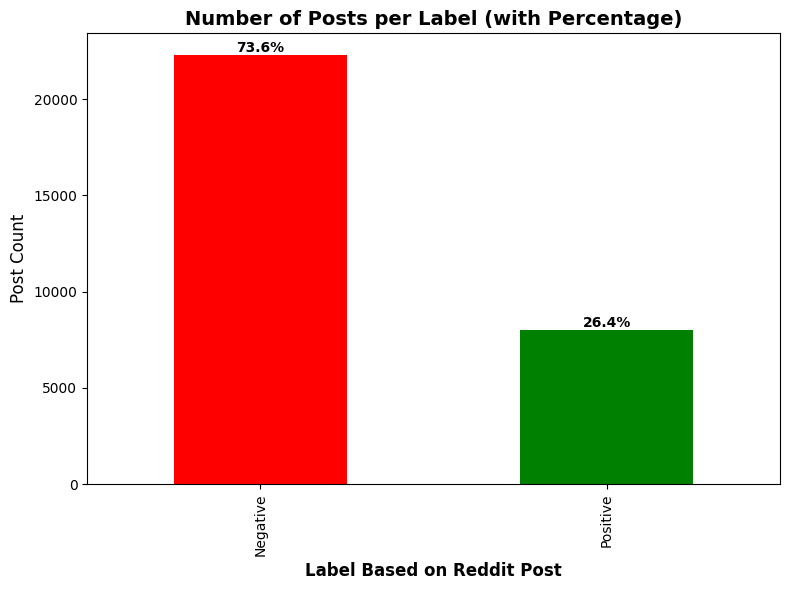

In [ ]:
plt.figure(figsize=(8, 6))
ax = Reddit_Label.plot(kind="bar", color=['red', 'green'])
total = Reddit_Label.sum()
for i, value in enumerate(Reddit_Label):
    percent = 100 * value / total
    ax.text(i, value + 0.5, f'{percent:.1f}%',
            ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.title("Number of Posts per Label (with Percentage)", fontsize=14, fontweight='bold')
plt.xlabel("Label Based on Reddit Post", fontsize=12, fontweight="bold")
plt.ylabel("Post Count", fontsize=12)
plt.tight_layout()
plt.show()

#### **Rule Based Using Vader**

###### VADER (Valence Aware Dictionary and sEntiment Reasoner) is a rule-based sentiment analysis tool designed for social media text. It uses a pre-built lexicon and considers word intensity, punctuation, capitalization, and emojis to determine sentiment scores positive, negative, neutral, and compound. Making it accurate for short, informal, and expressive online language.


###### Make a VADER analyzer to check how positive or negative text is

In [ ]:
analyzer = SentimentIntensityAnalyzer()

###### Let’s use the **VADER** sentiment analyzer to score each post’s emotional tone, then classify it as **Positive**, **Negative**, or **Neutral** based on the compound sentiment score.


In [ ]:
Dataset['compound'] = Dataset['text_lemma'].fillna('').apply(lambda x: analyzer.polarity_scores(x)['compound'])

In [ ]:
display(Dataset.head())

,id,subreddit,created_utc,text_raw,score,query,label,source,permalink,text_clean,text_lemma,compound
0,1hcho9i,UKJobs,1.733997e+09,If you knew you were getting replaced next mon...,2,job dissatisfaction,Negative,post,https://www.reddit.com/r/UKJobs/comments/1hcho...,if you knew you were getting replaced next mon...,know get replace next month wwyd I work remote...,-0.6249
1,1fjpfib,UKJobs,1.726655e+09,Unexpected negative feedback - should I resign...,13,job dissatisfaction,Negative,post,https://www.reddit.com/r/UKJobs/comments/1fjpf...,unexpected negative feedback should i resign i...,unexpected negative feedback I resign I recent...,0.4667
2,1f5sf4s,UKJobs,1.725125e+09,"Need Advice, Poor Mental & Physical Health wor...",3,job dissatisfaction,Negative,post,https://www.reddit.com/r/UKJobs/comments/1f5sf...,need advice poor mental physical health workin...,need advice poor mental physical health work f...,-0.2783
3,1bhj1hg,UKJobs,1.710739e+09,Struggling to get a fair salary I graduated f...,14,job dissatisfaction,Negative,post,https://www.reddit.com/r/UKJobs/comments/1bhj1...,struggling to get a fair salary i graduated fr...,struggle get fair salary I graduate top uni la...,0.9973
4,1aydktg,UKJobs,1.708727e+09,Update: still being forced to work weekends fo...,56,job dissatisfaction,Negative,post,https://www.reddit.com/r/UKJobs/comments/1aydk...,update still being forced to work weekends for...,update still force work weekend free hey I pos...,-0.7146


###### We have a new field called compound which was gotten from Vader. Let use the compound score to group their sentiment. According to Vader documentation. positive sentiment: compound score >= 0.05, neutral sentiment: (compound score > -0.05) and (compound score < 0.05), negative sentiment: compound score <= -0.05  

In [ ]:
Dataset['vader_sentiment'] = Dataset['vader_sentiment'] = Dataset['compound'].apply(lambda c: ('Positive' if c >= 0.05 else 'Negative' if c <= -0.05 else 'Neutral'))

###### Now we have sucessfully added the compound score and also a new column called vader sentiment which categorize them into Positive, Negative and Neutral

###### Let plot a bar chart showing how many posts are **Positive**, **Neutral**, or **Negative** according to VADER

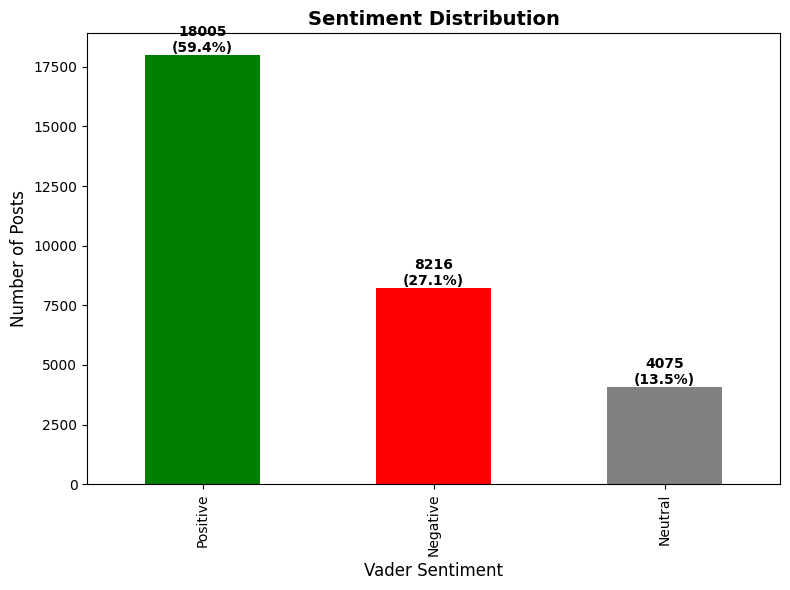

In [ ]:
sentiment_counts = Dataset['vader_sentiment'].value_counts()
total = sentiment_counts.sum()
plt.figure(figsize=(8, 6))
ax = sentiment_counts.plot(kind='bar', color=['green', 'red', 'gray'])
for i, value in enumerate(sentiment_counts):
    percent = 100 * value / total
    ax.text(i, value + 0.5,
            f'{value}\n({percent:.1f}%)',
            ha='center', va='bottom',
            fontsize=10, fontweight='bold')

plt.title('Sentiment Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Vader Sentiment', fontsize=12)
plt.ylabel('Number of Posts', fontsize=12)
plt.tight_layout()
plt.show()

###### let plot an histogram to show how the VADER compound scores are spread across all reviews

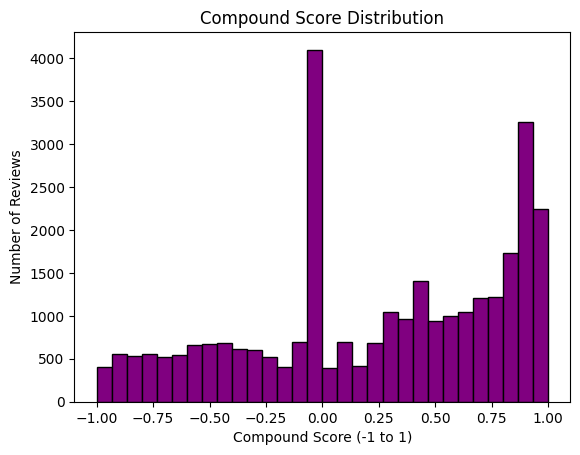

In [ ]:
plt.hist(Dataset['compound'], bins=30, color='purple', edgecolor='black')
plt.title('Compound Score Distribution')
plt.xlabel('Compound Score (-1 to 1)')
plt.ylabel('Number of Reviews')
plt.show()

###### Let create a word cloud of the most common words from positive posts

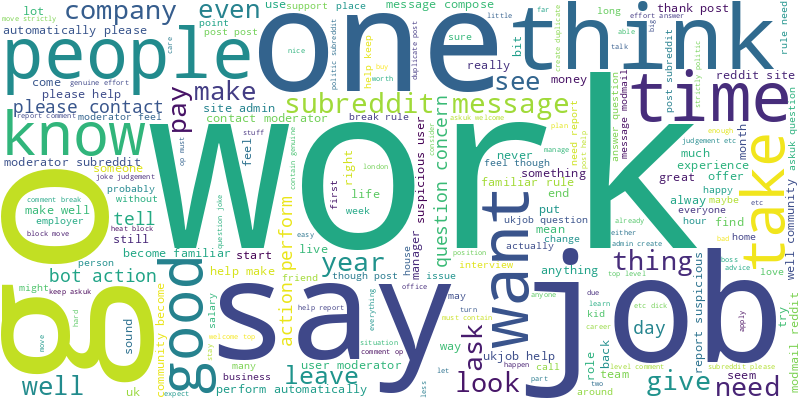

In [ ]:
pos_text = " ".join(Dataset[Dataset['vader_sentiment'] == 'Positive']['text_lemma'])
WordCloud(width=800, height=400, background_color='white').generate(pos_text).to_image()

WordCloud for the Negative word as well

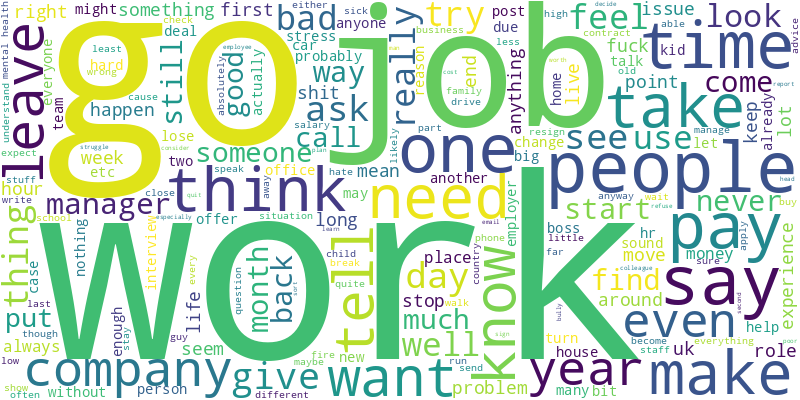

In [ ]:
pos_text = " ".join(Dataset[Dataset['vader_sentiment'] == 'Negative']['text_lemma'])
WordCloud(width=800, height=400, background_color='white').generate(pos_text).to_image()

###### Let print the most positive and most negative reviews based on the highest and lowest VADER compound scores

In [ ]:
print("Most Positive Review:")
print(Dataset.loc[Dataset['compound'].idxmax(), 'text_lemma'])

print("\nMost Negative Review:")
print(Dataset.loc[Dataset['compound'].idxmin(), 'text_lemma'])

Most Positive Review:
list labour manifesto policy think I read jave policy I pull fromt manifesto apology I miss first step deliver economic stability tough spending rule grow economy keep taxis inflation mortgage low possible cut nhs waiting time appointment week evening weekend pay crack tax avoidance non dom loophole launch new border security command hundred new specialist investigator use counter terror power smash criminal boat gang set great british energy publicly clean power company cut bill good boost energy security pay windfall tax oil gas giant crack antisocial behaviour neighbourhood police pay end wasteful contract tough new penalty offender new network youth hub recruit new teacher key subject set child life work future pay end tax break private school mission drive governemnt secure high sustained growth good job productivity growth every part country make everyone well cut bill create job deliver security cheap zero carbon electricity accelerate net zero halve seriou

#### **Rule Based Using TextBlob**

###### TextBlob is a Python library for processing textual data. It provides simple APIs for tasks like sentiment analysis, part-of-speech tagging, and noun phrase extraction. Using pre-trained models, TextBlob assigns polarity (positive or negative) and subjectivity scores, making it beginner-friendly for quickly analyzing text and building natural language processing applications.


###### Let's download TextBlob's required NLTK corpora (needed for sentiment analysis, translation, etc.)

In [ ]:
!python3 -m textblob.download_corpora

[nltk_data] Downloading package brown to /root/nltk_data...
[nltk_data]   Unzipping corpora/brown.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data] Downloading package conll2000 to /root/nltk_data...
[nltk_data]   Unzipping corpora/conll2000.zip.
[nltk_data] Downloading package movie_reviews to /root/nltk_data...
[nltk_data]   Unzipping corpora/movie_reviews.zip.
Finished.


###### Let calculate TextBlob sentiment scores for each text (polarity and subjectivity) and also display the first few rows to check the new columns

In [ ]:
Dataset['polarity'] = Dataset['text_lemma'].fillna('').apply(lambda x: TextBlob(x).sentiment.polarity)
Dataset['subjectivity'] = Dataset['text_lemma'].fillna('').apply(lambda x: TextBlob(x).sentiment.subjectivity)

print(Dataset.head())

        id subreddit   created_utc  \
0  1hcho9i    UKJobs  1.733997e+09   
1  1fjpfib    UKJobs  1.726655e+09   
2  1f5sf4s    UKJobs  1.725125e+09   
3  1bhj1hg    UKJobs  1.710739e+09   
4  1aydktg    UKJobs  1.708727e+09   

                                            text_raw  score  \
0  If you knew you were getting replaced next mon...      2   
1  Unexpected negative feedback - should I resign...     13   
2  Need Advice, Poor Mental & Physical Health wor...      3   
3  Struggling to get a fair salary  I graduated f...     14   
4  Update: still being forced to work weekends fo...     56   

                 query     label source  \
0  job dissatisfaction  Negative   post   
1  job dissatisfaction  Negative   post   
2  job dissatisfaction  Negative   post   
3  job dissatisfaction  Negative   post   
4  job dissatisfaction  Negative   post   

                                           permalink  \
0  https://www.reddit.com/r/UKJobs/comments/1hcho...   
1  https://www.reddit

###### Let's define a function to label TextBlob polarity scores as Positive, Negative, or Neutral

In [ ]:
def label_sentiment(score):
    if score > 0:
        return "Positive"
    elif score < 0:
        return "Negative"
    else:
        return "Neutral"

###### Apply the label_sentiment function to classify each TextBlob polarity score as Positive, Negative, or Neutral

In [ ]:
Dataset["Blob_Sentiment"] = Dataset["polarity"].apply(label_sentiment)

###### Let's count how many posts fall into each TextBlob sentiment category (Positive, Negative, Neutral)

In [ ]:
sentiment_counts = Dataset["Blob_Sentiment"].value_counts()

In [ ]:
print(sentiment_counts)

Blob_Sentiment
Positive    17977
Negative     7311
Neutral      5008
Name: count, dtype: int64


###### Let plot a bar chart showing how many reviews are Positive, Neutral, or Negative based on TextBlob sentiment

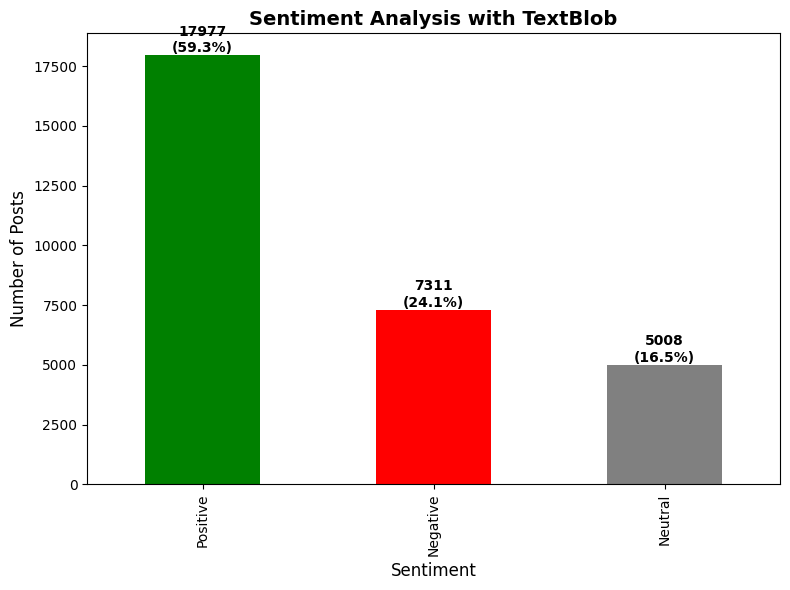

In [ ]:
sentiment_counts = sentiment_counts
total = sentiment_counts.sum()
plt.figure(figsize=(8, 6))
ax = sentiment_counts.plot(kind='bar', color=['green', 'red', 'gray'])
for i, value in enumerate(sentiment_counts):
    percent = 100 * value / total
    ax.text(i, value + 0.5,
            f'{value}\n({percent:.1f}%)',
            ha='center', va='bottom',
            fontsize=10, fontweight='bold')

plt.title('Sentiment Analysis with TextBlob', fontsize=14, fontweight='bold')
plt.xlabel('Sentiment', fontsize=12)
plt.ylabel('Number of Posts', fontsize=12)
plt.tight_layout()
plt.show()

#### **Using Transformer**

##### I loaded a Reddit-trained sentiment model and set up a pipeline to score each text in my dataset. Then I wrote a function that runs the sentiment analysis in batches, picks the highest-scoring label, and adds the sentiment results back into the dataset. Finally, I printed a small preview to check that everything worked.

In [ ]:
MODEL_NAME = "spacesedan/reddit-sentiment-analysis-longformer"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)

clf = pipeline(
    task="sentiment-analysis",
    model=model,
    tokenizer=tokenizer,
    return_all_scores=True,
    truncation=True,
    max_length=128,
)

def _batch_hf_sentiment(text_series: pd.Series, batch_size: int = 64) -> pd.DataFrame:
    """
    Run HF sentiment in batches over a pandas Series of text and return
    a DataFrame with columns: neg, neu, pos, sentiment (string label).
    """
    text_series = text_series.fillna("").astype(str)

    outputs = clf(list(text_series), batch_size=batch_size)

    rows = []
    for scores in outputs:
        label_to_score = {d["label"].lower(): float(d["score"]) for d in scores}
        top_label = max(label_to_score, key=label_to_score.get)

        rows.append({
            "neg": label_to_score.get("negative"),
            "neu": label_to_score.get("neutral"),
            "pos": label_to_score.get("positive"),
            "sentiment": top_label
        })

    return pd.DataFrame(rows, index=text_series.index)

Dataset_scores = _batch_hf_sentiment(Dataset["text_lemma"])

Dataset = pd.concat([Dataset, Dataset_scores], axis=1)

print(Dataset[["text_lemma", "sentiment"]].head())

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/958 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/595M [00:00<?, ?B/s]

Device set to use cuda:0
/usr/local/lib/python3.12/dist-packages/transformers/pipelines/text_classification.py:111: UserWarning: `return_all_scores` is now deprecated,  if want a similar functionality use `top_k=None` instead of `return_all_scores=True` or `top_k=1` instead of `return_all_scores=False`.
  warnings.warn(
Initializing global attention on CLS token...
Input ids are automatically padded to be a multiple of `config.attention_window`: 512


                                          text_lemma      sentiment
0  know get replace next month wwyd I work remote...  very negative
1  unexpected negative feedback I resign I recent...  very positive
2  need advice poor mental physical health work f...  very positive
3  struggle get fair salary I graduate top uni la...       positive
4  update still force work weekend free hey I pos...        neutral


##### **Visualization for Transformer**

In [ ]:
display(Dataset)

,id,subreddit,created_utc,text_raw,score,query,label,source,permalink,text_clean,text_lemma,compound,vader_sentiment,polarity,subjectivity,Blob_Sentiment,neg,neu,pos,sentiment
0,1hcho9i,UKJobs,1.733997e+09,If you knew you were getting replaced next mon...,2,job dissatisfaction,Negative,post,https://www.reddit.com/r/UKJobs/comments/1hcho...,if you knew you were getting replaced next mon...,know get replace next month wwyd I work remote...,-0.6249,Negative,-0.038095,0.204762,Negative,0.208530,0.100478,0.006163,very negative
1,1fjpfib,UKJobs,1.726655e+09,Unexpected negative feedback - should I resign...,13,job dissatisfaction,Negative,post,https://www.reddit.com/r/UKJobs/comments/1fjpf...,unexpected negative feedback should i resign i...,unexpected negative feedback I resign I recent...,0.4667,Positive,0.078185,0.504388,Positive,0.038291,0.026301,0.010316,very positive
2,1f5sf4s,UKJobs,1.725125e+09,"Need Advice, Poor Mental & Physical Health wor...",3,job dissatisfaction,Negative,post,https://www.reddit.com/r/UKJobs/comments/1f5sf...,need advice poor mental physical health workin...,need advice poor mental physical health work f...,-0.2783,Negative,0.049188,0.450429,Positive,0.181327,0.122396,0.052171,very positive
3,1bhj1hg,UKJobs,1.710739e+09,Struggling to get a fair salary I graduated f...,14,job dissatisfaction,Negative,post,https://www.reddit.com/r/UKJobs/comments/1bhj1...,struggling to get a fair salary i graduated fr...,struggle get fair salary I graduate top uni la...,0.9973,Positive,0.131252,0.502836,Positive,0.135446,0.059553,0.581526,positive
4,1aydktg,UKJobs,1.708727e+09,Update: still being forced to work weekends fo...,56,job dissatisfaction,Negative,post,https://www.reddit.com/r/UKJobs/comments/1aydk...,update still being forced to work weekends for...,update still force work weekend free hey I pos...,-0.7146,Negative,0.011024,0.486741,Positive,0.098685,0.331823,0.218751,neutral
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30291,lm0jiyl,recruitinghell,1.725744e+09,yes. Scrolling on indeed and seeing all shitty...,1,fair pay,Positive,comment,https://www.reddit.com/r/recruitinghell/commen...,yes scrolling on indeed and seeing all shitty ...,yes scroll indeed see shitty jobing post know ...,-0.6381,Negative,0.100000,0.600000,Positive,0.033349,0.180660,0.008430,very negative
30292,khzms0l,recruitinghell,1.705339e+09,The discord for our subreddit can be found her...,1,fair pay,Positive,comment,https://www.reddit.com/r/recruitinghell/commen...,the discord for our subreddit can be found her...,discord subreddit find feel free join realtime...,0.6249,Positive,0.250000,0.450000,Positive,0.024111,0.896784,0.007900,neutral
30293,khzsesf,recruitinghell,1.705340e+09,I earn less per hour as salaried engineer in u...,2,fair pay,Positive,comment,https://www.reddit.com/r/recruitinghell/commen...,i earn less per hour as salaried engineer in u...,I earn less per hour salaried engineer uk gran...,0.3612,Positive,0.041667,0.200000,Positive,0.030297,0.821490,0.010187,neutral
30294,khztd9y,recruitinghell,1.705341e+09,>...I'm sorry 4 hours? a week? A day? Either w...,2,fair pay,Positive,comment,https://www.reddit.com/r/recruitinghell/commen...,i'm sorry 4 hours a week a day either way 14 a...,I sorry hour week day either way hour come clo...,-0.0000,Neutral,-0.138384,0.494444,Negative,0.027207,0.031363,0.016762,very positive


###### Because the Transformer we used is 5-point sentiment classification. we need to merge Very positive with postive and very Negative with Negative and plot our chart

In [ ]:
Dataset['sentiment'] = Dataset['sentiment'].replace('negative', 'Negative')
Dataset['sentiment'] = Dataset['sentiment'].replace('positive', 'Positive')
Dataset['sentiment'] = Dataset['sentiment'].replace('neutral', 'Neutral')
Dataset['sentiment'] = Dataset['sentiment'].replace('very negative', 'Negative')
Dataset['sentiment'] = Dataset['sentiment'].replace('very positive', 'Positive')

In [ ]:
Dataset['sentiment'].value_counts()

,count
sentiment,
Neutral,17732
Negative,6655
Positive,5909


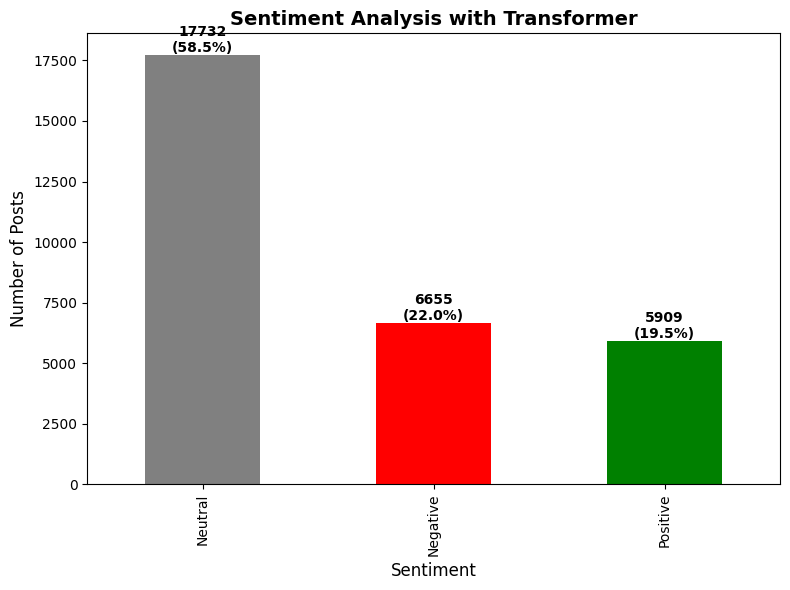

In [ ]:
sentiment_counts = Dataset['sentiment'].value_counts()
total = sentiment_counts.sum()
plt.figure(figsize=(8, 6))
ax = sentiment_counts.plot(kind='bar', color=['gray', 'red', 'green'])
for i, value in enumerate(sentiment_counts):
    percent = 100 * value / total
    ax.text(i, value + 0.5,
            f'{value}\n({percent:.1f}%)',
            ha='center', va='bottom',
            fontsize=10, fontweight='bold')

plt.title('Sentiment Analysis with Transformer', fontsize=14, fontweight='bold')
plt.xlabel('Sentiment', fontsize=12)
plt.ylabel('Number of Posts', fontsize=12)
plt.tight_layout()
plt.show()

### **Comparison between Vader, TextBlob and Transformer**

###### VADER handles social media text and slang better, while TextBlob is simpler, offering broader NLP features but less accurate on informal language.

###### Let's Compare the number of Positive, Neutral, and Negative sentiments between TextBlob and VADER and also Combine both results into one DataFrame for easy comparison then display them

In [ ]:
textblob_counts = Dataset["Blob_Sentiment"].value_counts()
vader_counts = Dataset["vader_sentiment"].value_counts()
Transformer_counts = Dataset["sentiment"].value_counts()

comparison = pd.DataFrame({
    "TextBlob": textblob_counts,
    "VADER": vader_counts,
    "Transformer(twitter-roberta-base-sentiment-latest)": Transformer_counts

})

display(comparison)

,TextBlob,VADER,Transformer(twitter-roberta-base-sentiment-latest)
Negative,7311,8216,6655
Neutral,5008,4075,17732
Positive,17977,18005,5909


###### Plotting a side-by-side bar chart to compare TextBlob and VADER sentiment results.

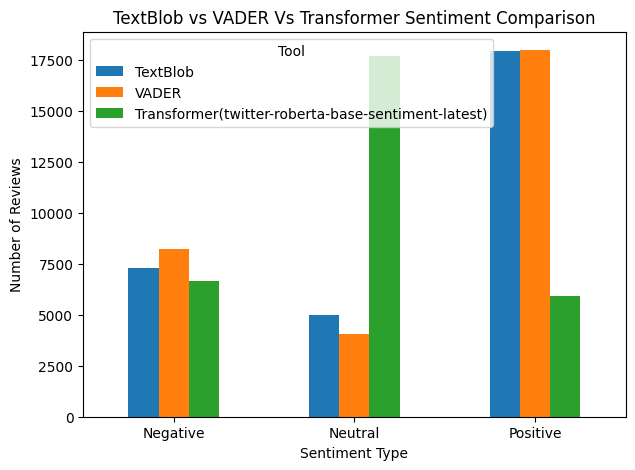

In [ ]:
comparison.plot(kind="bar", figsize=(7,5))
plt.title("TextBlob vs VADER Vs Transformer Sentiment Comparison")
plt.xlabel("Sentiment Type")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.legend(title="Tool")
plt.show()

#### **Model Agreement**

###### Let’s check how consistent our sentiment models are! We’ll see what percentage of samples all four models agree on and how often at least two models share the same sentiment.

In [ ]:
from collections import Counter

Dataset["all_agree"] = (
    (Dataset["vader_sentiment"] == Dataset["Blob_Sentiment"]) &
    (Dataset["vader_sentiment"] == Dataset["sentiment"])
)

all_agree_rate = Dataset['all_agree'].mean()

def majority_agreement(row):
    votes = [row['vader_sentiment'], row['Blob_Sentiment'], row['sentiment'], row['label']]
    return len(set(votes)) < 2

Dataset['two_or_more_agree'] = Dataset.apply(majority_agreement, axis=1)
two_plus_agree_rate = Dataset['two_or_more_agree'].mean()

print(f"All 3 labelling models agree on {all_agree_rate:.2%} of samples")
print(f"At least two models agree on {two_plus_agree_rate:.2%} of samples")

All 3 labelling models agree on 25.40% of samples
At least two models agree on 7.90% of samples


#### **Average confidence**

###### Let’s evaluate how confident each sentiment model is in its predictions. We calculate absolute confidence scores for **VADER**, **TextBlob**, and the **Transformer model**, then compare their average confidence levels to see which model shows the strongest overall certainty.

In [ ]:
# VADER and TextBlob confidence (absolute values)
Dataset['vader_strength'] = Dataset['compound'].abs()
Dataset['textblob_strength'] = Dataset['polarity'].abs()

# Transformer confidence = highest probability among negative, neutral, positive
Dataset['transformer_strength'] = Dataset[['neg', 'neu', 'pos']].max(axis=1)

# Print average confidence for all three
print("Average VADER confidence:", Dataset['vader_strength'].mean())
print("Average TextBlob confidence:", Dataset['textblob_strength'].mean())
print("Average Transformer confidence:", Dataset['transformer_strength'].mean())

Average VADER confidence: 0.5175448607076842
Average TextBlob confidence: 0.1690415416270866
Average Transformer confidence: 0.6296322590564256


###### Let’s visualize the average confidence levels of our three sentiment models **VADER**, **TextBlob**, and **Transformer** using a clear bar chart to see which model makes predictions with the most certainty!

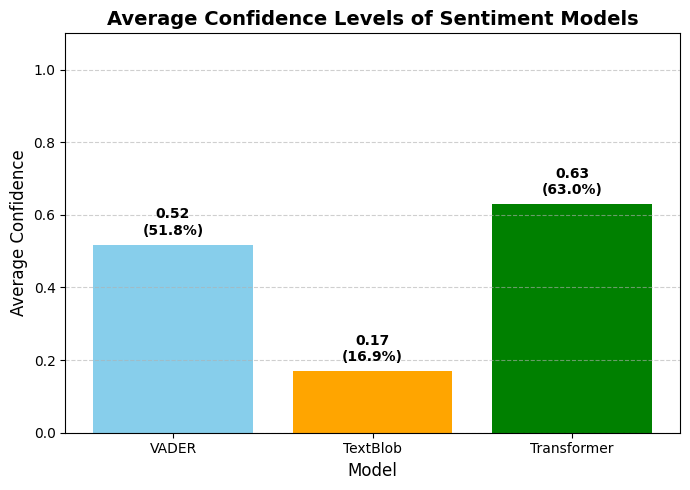

In [ ]:
avg_confidences = {
    'VADER': Dataset['vader_strength'].mean(),
    'TextBlob': Dataset['textblob_strength'].mean(),
    'Transformer': Dataset['transformer_strength'].mean()
}

plt.figure(figsize=(7, 5))
ax = plt.bar(avg_confidences.keys(), avg_confidences.values(),
             color=['skyblue', 'orange', 'green'])

for i, (model, value) in enumerate(avg_confidences.items()):
    percent = value * 100
    plt.text(i, value + 0.02,
             f"{value:.2f}\n({percent:.1f}%)",
             ha='center', va='bottom', fontsize=10, fontweight='bold', color='black')

plt.title("Average Confidence Levels of Sentiment Models", fontsize=14, fontweight='bold')
plt.xlabel("Model", fontsize=12)
plt.ylabel("Average Confidence", fontsize=12)
plt.ylim(0, 1.1)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

###### The comparison of average confidence levels reveals that the Transformer model produces the strongest and most confident sentiment predictions, followed by VADER, while TextBlob shows the weakest overall confidence on the Reddit dataset.

#### **Saving the Sentiment Labelling Dataset**

In [ ]:
Dataset.to_csv('2024_JOB_Dissatisfaction_Sentiment.csv', index=False)

In [ ]:
Dataset = pd.read_csv('2024_JOB_Dissatisfaction_Sentiment.csv')

#### **Traditional Model**

###### We will start by training with traditional model. We are using **Naive Bayes & SVM**

###### Let make a copy of our Dataset

In [ ]:
Dataframe = Dataset.copy()

#### **Naive Bayes**

#### **Naive Bayes Function**

###### So here, we’re building a balanced sentiment model. Basically, we convert our text into **TF-IDF features**, change the sentiment labels into numbers, handle **class imbalance with class weight**, train a **Naive Bayes model**, and then test how accurate it is.

In [ ]:
general_results = []

In [ ]:
Result_global = []

In [ ]:
def train_sentiment_model(dataframe, sentiment_col, use_class_weight=True):
    """
    Train a TF-IDF + MultinomialNB sentiment classifier.
    If use_class_weight=True, compute balanced class weights and pass them
    as per-sample weights to MultinomialNB.fit().
    """

    df = dataframe.copy()

    # Map sentiment labels to numeric values
    label_map = {'Negative': 0, 'Positive': 1, 'Neutral': 2}
    df['label_mapped'] = df[sentiment_col].map(label_map)

    # Drop rows where sentiment is missing or unmapped
    df = df.dropna(subset=['label_mapped'])

    # Clean text_lemma
    df['text_lemma'] = df['text_lemma'].fillna('').astype(str)
    df = df[df['text_lemma'].str.strip() != '']

    # TF-IDF
    tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
    X = tfidf.fit_transform(df['text_lemma'])
    y = df['label_mapped']

    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42
    )

    # Compute class weights
    sample_weight_train = None
    if use_class_weight:
        classes = np.unique(y_train)
        weights = compute_class_weight(
            class_weight='balanced',
            classes=classes,
            y=y_train
        )
        class_weight_dict = {c: w for c, w in zip(classes, weights)}

        y_train_series = pd.Series(y_train).reset_index(drop=True)
        sample_weight_train = y_train_series.map(class_weight_dict).to_numpy()

        inv_label_map = {0: 'Negative', 1: 'Positive', 2: 'Neutral'}
        pretty_weights = {
            inv_label_map[c]: round(float(w), 4)
            for c, w in class_weight_dict.items()
        }
        print("Class weights (balanced):", pretty_weights)

    # Train model
    nb = MultinomialNB()
    nb.fit(X_train, y_train, sample_weight=sample_weight_train)

    # Predict
    y_pred = nb.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average="weighted")
    f1 = f1_score(y_test, y_pred, average="weighted")

    print("Accuracy:", round(accuracy, 4))
    print("Precision:", round(precision, 4))
    print("F1 Score:", round(f1, 4))

    print("\nClassification Report:")
    print(classification_report(
        y_test,
        y_pred,
        target_names=['Negative', 'Positive', 'Neutral']
    ))

    print("\nConfusion Matrix (rows=true, cols=pred):")
    print(confusion_matrix(y_test, y_pred))

    model_result = {
        "accuracy": round(float(accuracy), 4),
        "precision": round(float(precision), 4),
        "f1_score": round(float(f1), 4),
        "use_class_weight": use_class_weight,
        "labels": sentiment_col
    }

    general_results.append(model_result)

    return nb, tfidf, accuracy, model_result

###### We’re going to train our sentiment models using the **Naive Bayes** algorithm to compare their performance. The idea is to feed in the sentiment outputs from **VADER**, **TextBlob**, and the **Transformer model** separately, and then check which one gives us the best accuracy and overall results. By doing this, we’ll be able to see which sentiment detection method works best with our dataset and produces the most reliable predictions.


#### **Vader with Naive Bayes**

In [ ]:
Vader_Naive_Bayes = train_sentiment_model(Dataframe, 'vader_sentiment')

Class weights (balanced): {'Negative': 1.227, 'Positive': 0.56, 'Neutral': 2.5048}
Accuracy: 0.5668
Precision: 0.7251
F1 Score: 0.5762

Classification Report:
              precision    recall  f1-score   support

    Negative       0.45      0.81      0.58      1643
    Positive       0.93      0.44      0.60      3602
     Neutral       0.36      0.61      0.45       805

    accuracy                           0.57      6050
   macro avg       0.58      0.62      0.54      6050
weighted avg       0.73      0.57      0.58      6050


Confusion Matrix (rows=true, cols=pred):
[[1337   49  257]
 [1369 1602  631]
 [ 247   68  490]]


#### **Transformer with Naive Bayes**

In [ ]:
Transformer_Naive_Bayes = train_sentiment_model(Dataframe, 'sentiment')

Class weights (balanced): {'Negative': 1.5149, 'Positive': 1.7062, 'Neutral': 0.5702}
Accuracy: 0.5562
Precision: 0.7326
F1 Score: 0.5716

Classification Report:
              precision    recall  f1-score   support

    Negative       0.34      0.89      0.49      1331
    Positive       0.76      0.31      0.44      1182
     Neutral       0.87      0.51      0.65      3537

    accuracy                           0.56      6050
   macro avg       0.66      0.57      0.53      6050
weighted avg       0.73      0.56      0.57      6050


Confusion Matrix (rows=true, cols=pred):
[[1185   17  129]
 [ 675  366  141]
 [1626   97 1814]]


#### **Text Blob with Naive Bayes**

In [ ]:
TextBlob_Naive_Bayes = train_sentiment_model(Dataframe, 'Blob_Sentiment')

Class weights (balanced): {'Negative': 1.3789, 'Positive': 0.5608, 'Neutral': 2.0336}
Accuracy: 0.5764
Precision: 0.7335
F1 Score: 0.5812

Classification Report:
              precision    recall  f1-score   support

    Negative       0.40      0.87      0.55      1462
    Positive       0.91      0.43      0.58      3596
     Neutral       0.57      0.68      0.62       992

    accuracy                           0.58      6050
   macro avg       0.63      0.66      0.58      6050
weighted avg       0.73      0.58      0.58      6050


Confusion Matrix (rows=true, cols=pred):
[[1270   49  143]
 [1684 1546  366]
 [ 226   95  671]]


##### **Comparing the naive bayes result for the 4 labelling**

###### Let’s visualize how well each sentiment model performed after training with **Naive Bayes** This bar chart compares the accuracy of **VADER**, **TextBlob**, and **Transformer** labelling to see which one delivers the best overall results.

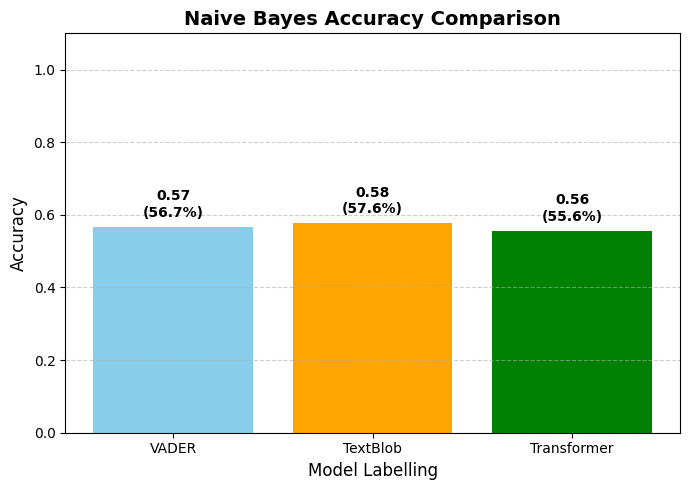

In [ ]:
Naive_Result = {
    'VADER': Vader_Naive_Bayes[2],
    'TextBlob': TextBlob_Naive_Bayes[2],
    'Transformer': Transformer_Naive_Bayes[2]
}

plt.figure(figsize=(7, 5))
ax = plt.bar(Naive_Result.keys(), Naive_Result.values(),
             color=['skyblue', 'orange', 'green'])

for i, (model, value) in enumerate(Naive_Result.items()):
    percent = value * 100
    plt.text(i, value + 0.02,
             f"{value:.2f}\n({percent:.1f}%)",  # shows both
             ha='center', va='bottom', fontsize=10, fontweight='bold', color='black')

plt.title("Naive Bayes Accuracy Comparison", fontsize=14, fontweight='bold')
plt.xlabel("Model Labelling", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.ylim(0, 1.1)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

###### Let’s neatly display our Naive Bayes accuracy results in a table using a DataFrame, so we can easily compare **VADER**, **TextBlob**, and **Transformer** model performances side by side.

In [ ]:
result_naive = pd.DataFrame(Naive_Result, index=[0])
display(result_naive)

,VADER,TextBlob,Transformer
0,0.566777,0.576364,0.556198


In [ ]:
print(general_results)

[{'accuracy': 0.5668, 'precision': 0.7251, 'f1_score': 0.5762, 'use_class_weight': True, 'labels': 'vader_sentiment'}, {'accuracy': 0.5562, 'precision': 0.7326, 'f1_score': 0.5716, 'use_class_weight': True, 'labels': 'sentiment'}, {'accuracy': 0.5764, 'precision': 0.7335, 'f1_score': 0.5812, 'use_class_weight': True, 'labels': 'Blob_Sentiment'}]


In [ ]:
data = {
    "Naive Bayes": general_results
}

Result_global.append(data)

##### **SVM (Support Vector Machine)**

###### We’re now training a sentiment model using **Support Vector Machine (LinearSVC)** instead of Naive Bayes. We map the labels, turn the cleaned text into TF-IDF features, split the data, train the SVM with class balancing, and then check accuracy, report, and confusion matrix.

In [ ]:
general_results = []

In [ ]:
def train_svm_sentiment_model(dataframe, sentiment_col):
    """
    Train a TF-IDF + LinearSVC sentiment classifier
    for labels: Negative, Positive, Neutral.

    Also computes accuracy, precision, and F1-score (weighted),
    stores them in a result object, and appends it to the global
    general_results list.
    """

    df = dataframe.copy()

    # Map sentiment labels to numeric values
    label_map = {'Negative': 0, 'Positive': 1, 'Neutral': 2}
    df['label_mapped'] = df[sentiment_col].map(label_map)

    # Drop rows where sentiment is missing or unmapped
    df = df.dropna(subset=['label_mapped'])

    # Clean text_lemma: replace NaN/None with "", ensure string
    df['text_lemma'] = df['text_lemma'].fillna('').astype(str)

    # Drop completely empty texts
    df = df[df['text_lemma'].str.strip() != '']

    # Text → TF-IDF features
    tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
    X = tfidf.fit_transform(df['text_lemma'])
    y = df['label_mapped'].astype(int)

    # Train/test split (stratified)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42
    )

    # Train Linear SVM with balanced class weights
    svm = LinearSVC(class_weight='balanced', random_state=42)
    svm.fit(X_train, y_train)

    # Predict & evaluate
    y_pred = svm.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average="weighted")
    f1 = f1_score(y_test, y_pred, average="weighted")

    print("Accuracy:", round(accuracy, 4))
    print("Precision (weighted):", round(precision, 4))
    print("F1 Score (weighted):", round(f1, 4))

    print("\nClassification Report:")
    target_names = ['Negative', 'Positive', 'Neutral']
    print(classification_report(y_test, y_pred, target_names=target_names))

    print("\nConfusion Matrix (rows=true, cols=pred):")
    print(confusion_matrix(y_test, y_pred))

    scores_array = [
        round(float(precision), 4),
        round(float(accuracy), 4),
        round(float(f1), 4)
    ]

    model_result = {
        "model_name": "LinearSVC",
        "use_class_weight": True,
        "scores": scores_array,
        "labels": sentiment_col
    }

    general_results.append(model_result)

    return svm, tfidf, accuracy, model_result

#### **Vader with SVM**

In [ ]:
Vader_SVM = train_svm_sentiment_model(Dataframe, 'vader_sentiment')

Accuracy: 0.8294
Precision (weighted): 0.8371
F1 Score (weighted): 0.8323

Classification Report:
              precision    recall  f1-score   support

    Negative       0.78      0.77      0.77      1643
    Positive       0.91      0.88      0.90      3602
     Neutral       0.61      0.73      0.66       805

    accuracy                           0.83      6050
   macro avg       0.77      0.79      0.78      6050
weighted avg       0.84      0.83      0.83      6050


Confusion Matrix (rows=true, cols=pred):
[[1258  201  184]
 [ 234 3169  199]
 [ 112  102  591]]


#### **Transformer with SVM**

In [ ]:
Transformer_SVM = train_svm_sentiment_model(Dataframe, 'sentiment')

Accuracy: 0.8018
Precision (weighted): 0.7991
F1 Score (weighted): 0.8001

Classification Report:
              precision    recall  f1-score   support

    Negative       0.66      0.62      0.64      1331
    Positive       0.81      0.77      0.79      1182
     Neutral       0.85      0.88      0.86      3537

    accuracy                           0.80      6050
   macro avg       0.77      0.76      0.76      6050
weighted avg       0.80      0.80      0.80      6050


Confusion Matrix (rows=true, cols=pred):
[[ 824  101  406]
 [ 120  910  152]
 [ 314  106 3117]]


#### **Text Blob with SVM**

In [ ]:
TextBlob_SVM = train_svm_sentiment_model(Dataframe, 'Blob_Sentiment')

Accuracy: 0.8873
Precision (weighted): 0.8899
F1 Score (weighted): 0.8877

Classification Report:
              precision    recall  f1-score   support

    Negative       0.83      0.81      0.82      1462
    Positive       0.94      0.91      0.92      3596
     Neutral       0.81      0.93      0.86       992

    accuracy                           0.89      6050
   macro avg       0.86      0.88      0.87      6050
weighted avg       0.89      0.89      0.89      6050


Confusion Matrix (rows=true, cols=pred):
[[1183  180   99]
 [ 207 3266  123]
 [  39   34  919]]


#### **Comparing the 4 result for SVM**

###### Let’s visualize how each sentiment model performed when trained with **SVM**! This bar chart compares the accuracy of **VADER**, **TextBlob**, and **Transformer** labelling, helping us see which one delivers the highest performance with the SVM classifier.


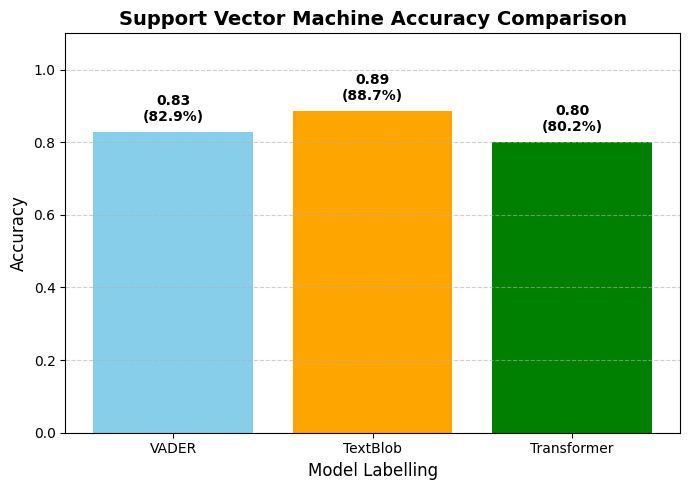

In [ ]:
SVM_Result = {
    'VADER': Vader_SVM[2],
    'TextBlob': TextBlob_SVM[2],
    'Transformer': Transformer_SVM[2]
}

plt.figure(figsize=(7, 5))
ax = plt.bar(SVM_Result.keys(), SVM_Result.values(),
             color=['skyblue', 'orange', 'green'])

for i, (model, value) in enumerate(SVM_Result.items()):
    percent = value * 100
    plt.text(i, value + 0.02,
             f"{value:.2f}\n({percent:.1f}%)",  # shows both
             ha='center', va='bottom', fontsize=10, fontweight='bold', color='black')

plt.title("Support Vector Machine Accuracy Comparison", fontsize=14, fontweight='bold')
plt.xlabel("Model Labelling", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.ylim(0, 1.1)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [ ]:
result_svm = pd.DataFrame(SVM_Result, index=[0])
display(result_svm)

,VADER,TextBlob,Transformer
0,0.829421,0.887273,0.801818


In [ ]:
data = {
    "SVM": general_results
}

Result_global.append(data)

In [ ]:
display(Result_global)

[{'Naive Bayes': [{'accuracy': 0.5668,
    'precision': 0.7251,
    'f1_score': 0.5762,
    'use_class_weight': True,
    'labels': 'vader_sentiment'},
   {'accuracy': 0.5562,
    'precision': 0.7326,
    'f1_score': 0.5716,
    'use_class_weight': True,
    'labels': 'sentiment'},
   {'accuracy': 0.5764,
    'precision': 0.7335,
    'f1_score': 0.5812,
    'use_class_weight': True,
    'labels': 'Blob_Sentiment'}]},
 {'SVM': [{'model_name': 'LinearSVC',
    'use_class_weight': True,
    'scores': [0.8371, 0.8294, 0.8323],
    'labels': 'vader_sentiment'},
   {'model_name': 'LinearSVC',
    'use_class_weight': True,
    'scores': [0.7991, 0.8018, 0.8001],
    'labels': 'sentiment'},
   {'model_name': 'LinearSVC',
    'use_class_weight': True,
    'scores': [0.8899, 0.8873, 0.8877],
    'labels': 'Blob_Sentiment'}]}]

### **Deep Learning Model**

###### We’re going to build two deep learning models **BERT** and a **CNN for text** to train and compare performance across the **VADER**, **TextBlob**, and **Transformer** sentiment datasets.

###### Let make the copy of the dataset

In [ ]:
df = Dataset.copy()

#### **CNN for Text**

###### We’re training a **CNN-based deep learning model** for sentiment analysis. The text is tokenized, padded, and converted into embeddings so the model can learn meaningful word patterns. Using convolutional and dense layers, it classifies posts as **Positive**, **Negative**, or **Neutral**, while class weights ensure balanced learning and accurate evaluation results.

In [ ]:
general_results = []

In [ ]:
def train_cnn_sentiment_model(
    dataframe, sentiment_col, max_words=10000, max_len=200,
    embedding_dim=100, epochs=5, batch_size=64
):
    df = dataframe.copy()

    # Map sentiment labels to numeric values
    label_map = {'Negative': 0, 'Positive': 1, 'Neutral': 2}
    df['label_mapped'] = df[sentiment_col].map(label_map)

    # Drop rows where sentiment is missing or unmapped
    df = df.dropna(subset=['label_mapped'])

    # Clean text_lemma
    df['text_lemma'] = df['text_lemma'].fillna('').astype(str)
    df = df[df['text_lemma'].str.strip() != '']

    y = df['label_mapped'].values

    # Tokenize text data
    tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
    tokenizer.fit_on_texts(df['text_lemma'])
    sequences = tokenizer.texts_to_sequences(df['text_lemma'])
    X = pad_sequences(sequences, maxlen=max_len, padding='post', truncating='post')

    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42
    )

    # Compute class weights
    class_weights = compute_class_weight(
        class_weight='balanced',
        classes=np.unique(y_train),
        y=y_train
    )
    class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}
    print("\nClass Weights:", class_weight_dict)

    # Build CNN model
    model = Sequential([
        Embedding(input_dim=max_words, output_dim=embedding_dim, input_length=max_len),
        Conv1D(128, 5, activation='relu'),
        GlobalMaxPooling1D(),
        Dropout(0.5),
        Dense(64, activation='relu'),
        Dense(3, activation='softmax')  # 3 classes: Negative, Positive, Neutral
    ])

    # Compile model
    model.compile(
        loss='sparse_categorical_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )

    # Train model with class weights
    history = model.fit(
        X_train, y_train,
        validation_split=0.1,
        epochs=epochs,
        batch_size=batch_size,
        class_weight=class_weight_dict,
        verbose=1
    )

    # Evaluate model
    y_pred_probs = model.predict(X_test)
    y_pred = np.argmax(y_pred_probs, axis=1)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average="weighted")
    f1 = f1_score(y_test, y_pred, average="weighted")

    print("\nAccuracy:", round(accuracy, 4))
    print("Precision (weighted):", round(precision, 4))
    print("F1 Score (weighted):", round(f1, 4))

    print("\nClassification Report:")
    target_names = ['Negative', 'Positive', 'Neutral']
    print(classification_report(y_test, y_pred, target_names=target_names))

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    # Build scores array [precision, accuracy, f1]
    scores_array = [
        round(float(precision), 4),
        round(float(accuracy), 4),
        round(float(f1), 4)
    ]

    # Build result object
    model_result = {
        "model_name": "CNN",
        "use_class_weight": True,
        "scores": scores_array,
        "labels": sentiment_col
    }

    general_results.append(model_result)

    return model, tokenizer, accuracy, model_result

In [ ]:
print("NaNs in text_lemma:", df['text_lemma'].isna().sum())
print("Types in text_lemma:", df['text_lemma'].apply(type).value_counts())

NaNs in text_lemma: 50
Types in text_lemma: text_lemma
<class 'str'>      30246
<class 'float'>       50
Name: count, dtype: int64


In [ ]:
df['text_lemma'] = df['text_lemma'].fillna('')

df = df[~df['text_lemma'].apply(lambda x: isinstance(x, float))]

df['text_lemma'] = df['text_lemma'].astype(str)

print("NaNs in text_lemma:", df['text_lemma'].isna().sum())
print("Types in text_lemma:", df['text_lemma'].apply(type).value_counts())

NaNs in text_lemma: 0
Types in text_lemma: text_lemma
<class 'str'>    30296
Name: count, dtype: int64


#### **CNN with Vader Sentiment**

In [ ]:
Vader_CNN = train_cnn_sentiment_model(df, 'vader_sentiment')


Class Weights: {0: np.float64(1.227039910745981), 1: np.float64(0.5599759309403134), 2: np.float64(2.5047619047619047)}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/5
341/341 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.5571 - loss: 0.9300 - val_accuracy: 0.7938 - val_loss: 0.5397
Epoch 2/5
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8195 - loss: 0.4820 - val_accuracy: 0.8450 - val_loss: 0.4526
Epoch 3/5
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8983 - loss: 0.3080 - val_accuracy: 0.8231 - val_loss: 0.4919
Epoch 4/5
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9253 - loss: 0.2466 - val_accuracy: 0.8467 - val_loss: 0.4511
Epoch 5/5
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9474 - loss: 0.1856 - val_accuracy: 0.8388 - val_loss: 0.5063
190/190 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step

Accuracy: 0.8337
Precision (weighted): 0.841
F1 Score (weighted): 0.8355

Classification Report:
              precision    recall  f1-score   support

    Negative       0.71      0.83      0.76      1643
    Positive       0.90      0.86      0.88      3602
     Neutral       0.82      0.73      0.77       805

    ac

#### **CNN with Transformer**

In [ ]:
Transformer_CNN = train_cnn_sentiment_model(df, 'sentiment')


Class Weights: {0: np.float64(1.514901076884548), 1: np.float64(1.7062266412805867), 2: np.float64(0.570189701897019)}
Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


341/341 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.5621 - loss: 0.9328 - val_accuracy: 0.8045 - val_loss: 0.5267
Epoch 2/5
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8418 - loss: 0.4479 - val_accuracy: 0.8112 - val_loss: 0.4880
Epoch 3/5
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8820 - loss: 0.3200 - val_accuracy: 0.8058 - val_loss: 0.4945
Epoch 4/5
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9225 - loss: 0.2198 - val_accuracy: 0.8058 - val_loss: 0.5696
Epoch 5/5
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9482 - loss: 0.1510 - val_accuracy: 0.8045 - val_loss: 0.6086
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

Accuracy: 0.8086
Precision (weighted): 0.8145
F1 Score (weighted): 0.811

Classification Report:
              precision    recall  f1-score   support

    Negative       0.63      0.69      0.66      1331
    Positive       0.81      0.82      0.81      1182
     Neutral       0.89      0.85      0.87      3537

    accuracy     

#### **CNN with Text Blob**

In [ ]:
TextBlob_CNN = train_cnn_sentiment_model(df, 'Blob_Sentiment')


Class Weights: {0: np.float64(1.3789251723941414), 1: np.float64(0.5608325800245695), 2: np.float64(2.033619095646327)}
Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


341/341 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.5534 - loss: 0.8452 - val_accuracy: 0.8537 - val_loss: 0.3702
Epoch 2/5
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8678 - loss: 0.3095 - val_accuracy: 0.8909 - val_loss: 0.2786
Epoch 3/5
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9224 - loss: 0.1849 - val_accuracy: 0.8806 - val_loss: 0.3104
Epoch 4/5
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9487 - loss: 0.1268 - val_accuracy: 0.8926 - val_loss: 0.2927
Epoch 5/5
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9667 - loss: 0.0815 - val_accuracy: 0.8831 - val_loss: 0.3434
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

Accuracy: 0.8866
Precision (weighted): 0.8869
F1 Score (weighted): 0.8867

Classification Report:
              precision    recall  f1-score   support

    Negative       0.80      0.80      0.80      1462
    Positive       0.91      0.91      0.91      3596
     Neutral       0.93      0.91      0.92       992

    accuracy    

#### **Comparison of the 4 for CNN**

###### Let’s visualize how well our **CNN models** performed! This bar chart compares the accuracy of **VADER**, **TextBlob**, and **Transformer** sentiment labelling, with percentage values displayed on each bar to clearly show which model achieved the best performance.

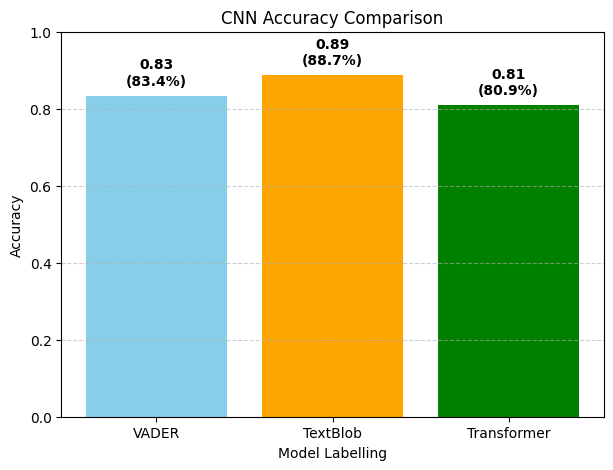

In [ ]:
CNN_Result = {
    'VADER': Vader_CNN[2],
    'TextBlob': TextBlob_CNN[2],
    'Transformer': Transformer_CNN[2],
}

plt.figure(figsize=(7,5))
ax = plt.bar(CNN_Result.keys(), CNN_Result.values(),
             color=['skyblue', 'orange', 'green'])

for i, (model, value) in enumerate(CNN_Result.items()):
    percent = value * 100
    plt.text(i, value + 0.02,
             f"{value:.2f}\n({percent:.1f}%)",  # shows both
             ha='center', va='bottom', fontsize=10, fontweight='bold', color='black')


plt.bar(CNN_Result.keys(), CNN_Result.values(), color=['skyblue','orange','green'])
plt.title("CNN Accuracy Comparison")
plt.xlabel("Model Labelling")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

###### Let’s display the **CNN model results** in a clean table using a DataFrame. This makes it easy to compare the accuracies of **VADER**, **TextBlob**, and **Transformer** sentiment models side by side and identify which one performed best.

In [ ]:
result_CNN = pd.DataFrame(CNN_Result, index=[0])
display(result_CNN)

,VADER,TextBlob,Transformer
0,0.833719,0.886612,0.808595


In [ ]:
data = {
    "CNN": general_results
}

Result_global.append(data)

In [ ]:
display(Result_global)

[{'Naive Bayes': [{'accuracy': 0.5668,
    'precision': 0.7251,
    'f1_score': 0.5762,
    'use_class_weight': True,
    'labels': 'vader_sentiment'},
   {'accuracy': 0.5562,
    'precision': 0.7326,
    'f1_score': 0.5716,
    'use_class_weight': True,
    'labels': 'sentiment'},
   {'accuracy': 0.5764,
    'precision': 0.7335,
    'f1_score': 0.5812,
    'use_class_weight': True,
    'labels': 'Blob_Sentiment'}]},
 {'SVM': [{'model_name': 'LinearSVC',
    'use_class_weight': True,
    'scores': [0.8371, 0.8294, 0.8323],
    'labels': 'vader_sentiment'},
   {'model_name': 'LinearSVC',
    'use_class_weight': True,
    'scores': [0.7991, 0.8018, 0.8001],
    'labels': 'sentiment'},
   {'model_name': 'LinearSVC',
    'use_class_weight': True,
    'scores': [0.8899, 0.8873, 0.8877],
    'labels': 'Blob_Sentiment'}]},
 {'CNN': [{'model_name': 'CNN',
    'use_class_weight': True,
    'scores': [0.841, 0.8337, 0.8355],
    'labels': 'vader_sentiment'},
   {'model_name': 'CNN',
    'use_cla

#### **Using Transformer BERT**

###### We’re fine-tuning a BERT model for sentiment analysis. We take the cleaned text, map each sentiment (Negative, Positive, Neutral) to numbers, split into train/test, tokenize with a pretrained BERT tokenizer, and train a sequence classification model. After training, we measure performance using accuracy, a classification report, and a confusion matrix.

In [ ]:
general_results = []

In [ ]:
class _SimpleDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(int(self.labels[idx]))
        return item


def train_bert_sentiment_model(
    dataframe,
    sentiment_col,
    text_col="text_lemma",
    model_name="bert-base-uncased",
    max_len=128,
    epochs=2,
    batch_size=16,
    learning_rate=2e-5,
    weight_decay=0.01,
    random_state=42
):
    # Map labels
    label_map = {"Negative": 0, "Positive": 1, "Neutral": 2}
    df = dataframe[[text_col, sentiment_col]].dropna().copy()
    df["label_mapped"] = df[sentiment_col].map(label_map)

    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        df[text_col].tolist(),
        df["label_mapped"].tolist(),
        test_size=0.2,
        stratify=df["label_mapped"],
        random_state=random_state
    )

    # Tokenizer & encodings
    tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
    train_enc = tokenizer(
        X_train, truncation=True, padding=False, max_length=max_len
    )
    test_enc = tokenizer(
        X_test, truncation=True, padding=False, max_length=max_len
    )

    train_ds = _SimpleDataset(train_enc, y_train)
    test_ds = _SimpleDataset(test_enc, y_test)

    # Model
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name, num_labels=3
    )

    collator = DataCollatorWithPadding(tokenizer=tokenizer)
    args = TrainingArguments(
        output_dir="bert_sentiment_outputs",
        eval_strategy="epoch",
        save_strategy="no",
        logging_strategy="epoch",
        learning_rate=learning_rate,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        num_train_epochs=epochs,
        weight_decay=weight_decay,
        report_to=[]
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_ds,
        eval_dataset=test_ds,
        tokenizer=tokenizer,
        data_collator=collator,
    )

    # Train
    trainer.train()

    # Predict
    preds = trainer.predict(test_ds)
    y_pred = np.argmax(preds.predictions, axis=1)

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average="weighted")
    f1 = f1_score(y_test, y_pred, average="weighted")

    print("\nAccuracy:", round(accuracy, 4))
    print("Precision (weighted):", round(precision, 4))
    print("F1 Score (weighted):", round(f1, 4))

    print("\nClassification Report:")
    target_names = ["Negative", "Positive", "Neutral"]
    print(classification_report(y_test, y_pred, target_names=target_names))

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    scores_array = [
        round(float(precision), 4),
        round(float(accuracy), 4),
        round(float(f1), 4)
    ]

    model_result = {
        "model_name": f"BERT ({model_name})",
        "use_class_weight": False,
        "scores": scores_array,
        "labels": sentiment_col
    }

    # Push into global results
    general_results.append(model_result)

    return model, tokenizer, trainer, accuracy, model_result

#### **Transformer with Vader**

In [ ]:
Vader_BERT = train_bert_sentiment_model(df, 'vader_sentiment', model_name="distilbert-base-uncased")

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-1217991567.py:70: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss
1,0.455300,0.315034
2,0.243100,0.296875



Accuracy: 0.9083
Precision (weighted): 0.9083
F1 Score (weighted): 0.9078

Classification Report:
              precision    recall  f1-score   support

    Negative       0.86      0.88      0.87      1643
    Positive       0.93      0.94      0.94      3602
     Neutral       0.91      0.81      0.85       815

    accuracy                           0.91      6060
   macro avg       0.90      0.88      0.89      6060
weighted avg       0.91      0.91      0.91      6060


Confusion Matrix:
[[1452  171   20]
 [ 160 3394   48]
 [  68   89  658]]


#### **Transformer with Transformer**

In [ ]:
Transformer_BERT = train_bert_sentiment_model(df, 'sentiment')

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-1217991567.py:70: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss
1,0.424300,0.314570
2,0.228300,0.333323



Accuracy: 0.886
Precision (weighted): 0.8889
F1 Score (weighted): 0.887

Classification Report:
              precision    recall  f1-score   support

    Negative       0.77      0.82      0.79      1331
    Positive       0.86      0.91      0.89      1182
     Neutral       0.94      0.90      0.92      3547

    accuracy                           0.89      6060
   macro avg       0.86      0.88      0.87      6060
weighted avg       0.89      0.89      0.89      6060


Confusion Matrix:
[[1085   96  150]
 [  58 1074   50]
 [ 262   75 3210]]


#### **Transformer with Transformer**

In [ ]:
TextBlob_BERT = train_bert_sentiment_model(df, 'Blob_Sentiment')

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-1217991567.py:70: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss
1,0.395300,0.239593
2,0.190200,0.226802



Accuracy: 0.9322
Precision (weighted): 0.9318
F1 Score (weighted): 0.9319

Classification Report:
              precision    recall  f1-score   support

    Negative       0.89      0.86      0.88      1462
    Positive       0.94      0.96      0.95      3596
     Neutral       0.95      0.93      0.94      1002

    accuracy                           0.93      6060
   macro avg       0.93      0.92      0.92      6060
weighted avg       0.93      0.93      0.93      6060


Confusion Matrix:
[[1262  166   34]
 [ 126 3455   15]
 [  29   41  932]]


#### **Comparison of the 3 for BERT**

###### Let’s visualize how well our **BERT models** performed across different sentiment labelling methods **VADER**, **TextBlob**, and **Transformer**. This bar chart compares their accuracy to reveal which dataset helped BERT achieve the best performance and most reliable predictions.


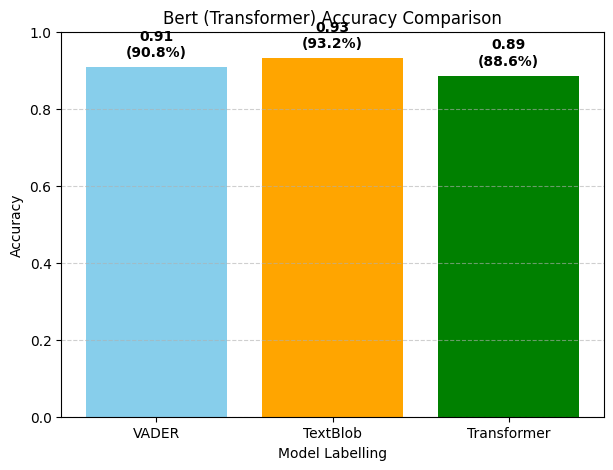

In [ ]:
BERT_Result = {
    'VADER': Vader_BERT[3],
    'TextBlob': TextBlob_BERT[3],
    'Transformer': Transformer_BERT[3]
}
plt.figure(figsize=(7,5))
ax = plt.bar(BERT_Result.keys(), BERT_Result.values(),
             color=['skyblue', 'orange', 'green'])

for i, (model, value) in enumerate(BERT_Result.items()):
    percent = value * 100
    plt.text(i, value + 0.02,
             f"{value:.2f}\n({percent:.1f}%)",  # shows both
             ha='center', va='bottom', fontsize=10, fontweight='bold', color='black')


plt.bar(BERT_Result.keys(), BERT_Result.values(), color=['skyblue','orange','green'])
plt.title("Bert (Transformer) Accuracy Comparison")
plt.xlabel("Model Labelling")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

###### Let’s neatly display our **BERT model results** in a table using a DataFrame. This makes it easy to compare the accuracy of **VADER**, **TextBlob**, and **Transformer** labelling side by side and identify which one produced the best overall performance.

In [ ]:
result_bert = pd.DataFrame(BERT_Result, index=[0])
display(result_bert)

,VADER,TextBlob,Transformer
0,0.908251,0.932178,0.885974


In [ ]:
data = {
    "Transformer": general_results
}

Result_global.append(data)

#### **Overall comparison for the 4 Model to know the best model**

###### Here we’re bringing everything together! This dictionary stores the **accuracy results** of all four models — **Naive Bayes**, **SVM**, **CNN**, and **BERT**. for each sentiment labelling method (**VADER**, **TextBlob**, and **Transformer**) so we can easily compare their performances later.

In [ ]:
results = {
    "CNN": {"VADER": Vader_CNN[2], "TextBlob": TextBlob_CNN[2], "Transformer": Transformer_CNN[2]},
    "SVM": {"VADER": Vader_SVM[2], "TextBlob": TextBlob_SVM[2], "Transformer": Transformer_SVM[2]},
    "Naive Bayes": {"VADER": Vader_Naive_Bayes[2], "TextBlob": TextBlob_Naive_Bayes[2], "Transformer": Transformer_Naive_Bayes[2]},
    "BERT": {"VADER": Vader_BERT[3], "TextBlob": TextBlob_BERT[3], "Transformer": Transformer_BERT[3]},
}

###### Let’s organize all our model performances into a clean table! By converting the results dictionary into a DataFrame, we can easily compare how **Naive Bayes**, **SVM**, **CNN**, and **BERT** performed across **VADER**, **TextBlob**, and **Transformer** labels all neatly rounded for clarity.

In [ ]:
results_df = pd.DataFrame(results).T
results_df = results_df.round(4)

display(results_df)

,VADER,TextBlob,Transformer
CNN,0.8337,0.8866,0.8086
SVM,0.8294,0.8873,0.8018
Naive Bayes,0.5668,0.5764,0.5562
BERT,0.9083,0.9322,0.8860


###### Let’s visualize the overall performance of all our models! This bar chart compares the accuracies of **Naive Bayes**, **SVM**, **CNN**, and **BERT** across the three sentiment sources **VADER**, **TextBlob**, and **Transformer** to clearly see which combination performed best.

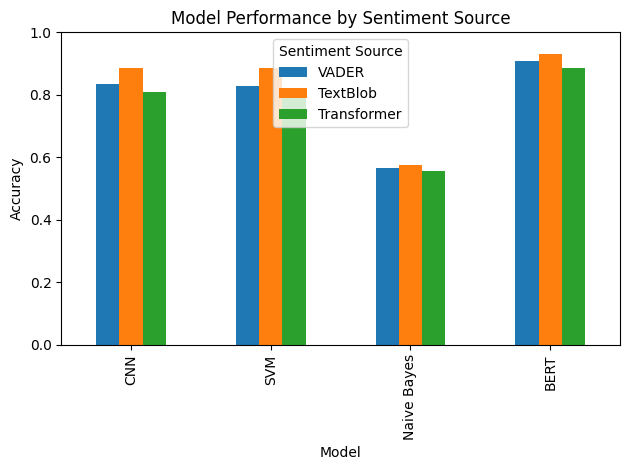

In [ ]:
ax = results_df.plot(kind='bar')
ax.set_title("Model Performance by Sentiment Source")
ax.set_xlabel("Model")
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1.0)
ax.legend(title="Sentiment Source", loc="best")
plt.tight_layout()
plt.show()

###### Let’s find out which model performed best for each sentiment source! This code checks the **highest accuracy** in each column and prints the **top-performing model** for **VADER**, **TextBlob**, and **Transformer** sentiment labelling.

In [ ]:
best_scores = results_df.idxmax()
print("Best models per sentiment source:")
print(best_scores)

Best models per sentiment source:
VADER          BERT
TextBlob       BERT
Transformer    BERT
dtype: object


###### Let’s create a **heatmap** to visualize model performance more clearly! Each cell shows the accuracy of **Naive Bayes**, **SVM**, **CNN**, and **BERT** across **VADER**, **TextBlob**, and **Transformer** labels, making it easy to spot the strongest results at a glance.

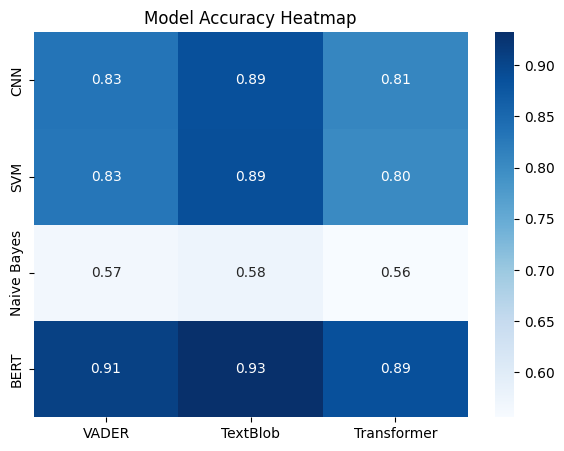

In [ ]:
plt.figure(figsize=(7,5))
sns.heatmap(results_df, annot=True, cmap="Blues", fmt=".2f")
plt.title("Model Accuracy Heatmap")
plt.show()

##### **Overall Labelling**

###### Let’s calculate the **average accuracy** for each sentiment source across all models. This helps us see whether **VADER**, **TextBlob**, or **Transformer** generally provided better training data for sentiment prediction overall.

In [ ]:
avg_scores = results_df.mean().sort_values(ascending=False)
print(avg_scores)

TextBlob       0.820625
VADER          0.784550
Transformer    0.763150
dtype: float64


###### Let’s visualize the **average accuracy** of each sentiment source across all models! This bar chart clearly shows whether **VADER**, **TextBlob**, or **Transformer** produced better overall results when used to train different sentiment classifiers.

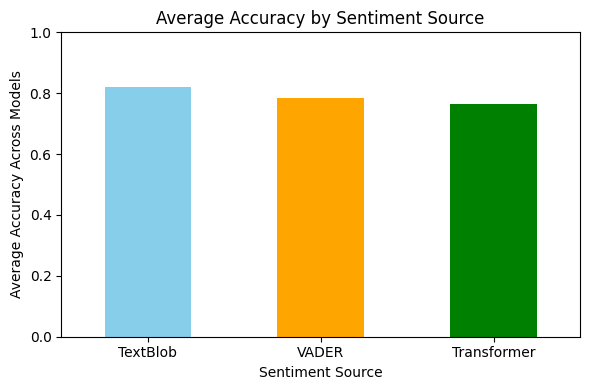

In [ ]:
plt.figure(figsize=(6,4))
avg_scores.plot(kind='bar', color=['skyblue', 'orange', 'green', 'red'])

plt.title('Average Accuracy by Sentiment Source')
plt.xlabel('Sentiment Source')
plt.ylabel('Average Accuracy Across Models')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

###### Let’s identify the **best overall sentiment source** This code finds which dataset **VADER**, **TextBlob**, or **Transformer** achieved the **highest average accuracy** across all models, then prints the top performer along with its exact score.

In [ ]:
best_source = avg_scores.idxmax()
best_score = avg_scores.max()
print(f"Best performing sentiment source: {best_source} ({best_score:.3f})")

Best performing sentiment source: TextBlob (0.821)


#### **For Model**

###### Let’s now check which **model** performed best on average across all sentiment sources. This code calculates the mean accuracy for each model  **Naive Bayes**, **SVM**, **CNN**, and **BERT** helping us see which one delivered the most consistent overall performance.

In [ ]:
avg_model_scores = results_df.mean(axis=1).sort_values(ascending=False)
print(avg_model_scores)

BERT           0.908833
CNN            0.842967
SVM            0.839500
Naive Bayes    0.566467
dtype: float64


###### Let’s visualize how each **model** performed on average across all sentiment sources! This bar chart compares the overall accuracy of **Naive Bayes**, **SVM**, **CNN**, and **BERT**, helping us easily see which model achieved the strongest and most reliable performance.

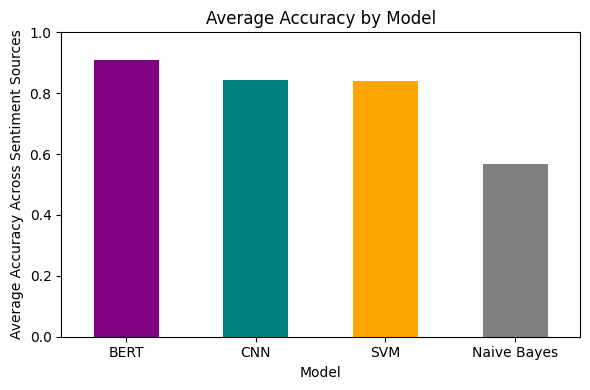

In [ ]:
plt.figure(figsize=(6,4))
avg_model_scores.plot(kind='bar', color=['purple', 'teal', 'orange', 'gray'])

plt.title('Average Accuracy by Model')
plt.xlabel('Model')
plt.ylabel('Average Accuracy Across Sentiment Sources')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

###### Let’s find out which **model** performed the best overall! This code identifies the model whether **Naive Bayes**, **SVM**, **CNN**, or **BERT** with the **highest average accuracy** across all sentiment sources and prints it along with its exact score.

In [ ]:
best_model = avg_model_scores.idxmax()
best_score = avg_model_scores.max()
print(f"Best performing model overall: {best_model} ({best_score:.3f})")

Best performing model overall: BERT (0.909)


###### Let’s save our cleaned and processed dataset! This line exports the entire **DataFrame** to a CSV file named **“Updated_Data.csv”**, excluding the index column, so we can easily reuse it for future analysis or modeling.

In [ ]:
Dataframe.to_csv('Updated_Data.csv', index=False)

In [ ]:
data = {
    "Transformer": general_results
}

Result_global.append(data)

In [ ]:
display(Result_global)

[{'Naive Bayes': [{'accuracy': 0.5668,
    'precision': 0.7251,
    'f1_score': 0.5762,
    'use_class_weight': True,
    'labels': 'vader_sentiment'},
   {'accuracy': 0.5562,
    'precision': 0.7326,
    'f1_score': 0.5716,
    'use_class_weight': True,
    'labels': 'sentiment'},
   {'accuracy': 0.5764,
    'precision': 0.7335,
    'f1_score': 0.5812,
    'use_class_weight': True,
    'labels': 'Blob_Sentiment'}]},
 {'SVM': [{'model_name': 'LinearSVC',
    'use_class_weight': True,
    'scores': [0.8371, 0.8294, 0.8323],
    'labels': 'vader_sentiment'},
   {'model_name': 'LinearSVC',
    'use_class_weight': True,
    'scores': [0.7991, 0.8018, 0.8001],
    'labels': 'sentiment'},
   {'model_name': 'LinearSVC',
    'use_class_weight': True,
    'scores': [0.8899, 0.8873, 0.8877],
    'labels': 'Blob_Sentiment'}]},
 {'CNN': [{'model_name': 'CNN',
    'use_class_weight': True,
    'scores': [0.841, 0.8337, 0.8355],
    'labels': 'vader_sentiment'},
   {'model_name': 'CNN',
    'use_cla

In [ ]:
with open("model_results.json", "r") as f:
    data = json.load(f)

print(data)

{'2020': [{'Naive Bayes': [{'accuracy': 0.6849, 'precision': 0.7254, 'f1_score': 0.7022, 'use_class_weight': True, 'labels': 'vader_sentiment'}, {'accuracy': 0.609, 'precision': 0.6354, 'f1_score': 0.6131, 'use_class_weight': True, 'labels': 'sentiment'}, {'accuracy': 0.7092, 'precision': 0.7184, 'f1_score': 0.7123, 'use_class_weight': True, 'labels': 'Blob_Sentiment'}]}, {'SVM': [{'model_name': 'LinearSVC', 'use_class_weight': True, 'scores': [0.8061, 0.8094, 0.8077], 'labels': 'vader_sentiment'}, {'model_name': 'LinearSVC', 'use_class_weight': True, 'scores': [0.712, 0.7134, 0.7124], 'labels': 'sentiment'}, {'model_name': 'LinearSVC', 'use_class_weight': True, 'scores': [0.8294, 0.8303, 0.8297], 'labels': 'Blob_Sentiment'}, {'model_name': 'CNN', 'use_class_weight': True, 'scores': [0.7618, 0.7578, 0.7597], 'labels': 'vader_sentiment'}, {'model_name': 'CNN', 'use_class_weight': True, 'scores': [0.7418, 0.7339, 0.7361], 'labels': 'sentiment'}, {'model_name': 'CNN', 'use_class_weight': 

In [ ]:
data['2024'] = Result_global

with open("model_results.json", "w") as file:
    json.dump(data, file, indent=4)

print("Result Saved Successfully")

Result Saved Successfully


### **Topic Modelling**

###### Topic modelling helps uncover hidden themes in text data, like identifying key reasons behind employee concerns in a **job dissatisfaction** dataset.

#### **LDA - Latent Dirichlet Allocation**

In [6]:
data = pd.read_csv('2024_JOB_Dissatisfaction_Sentiment.csv')

##### Displaying the datset to check if it's properly load

In [7]:
display(data)

,id,subreddit,created_utc,text_raw,score,query,label,source,permalink,text_clean,...,Blob_Sentiment,neg,neu,pos,sentiment,all_agree,two_or_more_agree,vader_strength,textblob_strength,transformer_strength
0,1hcho9i,UKJobs,1.733997e+09,If you knew you were getting replaced next mon...,2,job dissatisfaction,Negative,post,https://www.reddit.com/r/UKJobs/comments/1hcho...,if you knew you were getting replaced next mon...,...,Negative,0.208530,0.100478,0.006163,Negative,True,True,0.6249,0.038095,0.208530
1,1fjpfib,UKJobs,1.726655e+09,Unexpected negative feedback - should I resign...,13,job dissatisfaction,Negative,post,https://www.reddit.com/r/UKJobs/comments/1fjpf...,unexpected negative feedback should i resign i...,...,Positive,0.038291,0.026301,0.010316,Positive,True,False,0.4667,0.078185,0.038291
2,1f5sf4s,UKJobs,1.725125e+09,"Need Advice, Poor Mental & Physical Health wor...",3,job dissatisfaction,Negative,post,https://www.reddit.com/r/UKJobs/comments/1f5sf...,need advice poor mental physical health workin...,...,Positive,0.181327,0.122396,0.052171,Positive,False,False,0.2783,0.049188,0.181327
3,1bhj1hg,UKJobs,1.710739e+09,Struggling to get a fair salary I graduated f...,14,job dissatisfaction,Negative,post,https://www.reddit.com/r/UKJobs/comments/1bhj1...,struggling to get a fair salary i graduated fr...,...,Positive,0.135446,0.059553,0.581526,Positive,True,False,0.9973,0.131252,0.581526
4,1aydktg,UKJobs,1.708727e+09,Update: still being forced to work weekends fo...,56,job dissatisfaction,Negative,post,https://www.reddit.com/r/UKJobs/comments/1aydk...,update still being forced to work weekends for...,...,Positive,0.098685,0.331823,0.218751,Neutral,False,False,0.7146,0.011024,0.331823
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30291,lm0jiyl,recruitinghell,1.725744e+09,yes. Scrolling on indeed and seeing all shitty...,1,fair pay,Positive,comment,https://www.reddit.com/r/recruitinghell/commen...,yes scrolling on indeed and seeing all shitty ...,...,Positive,0.033349,0.180660,0.008430,Negative,False,False,0.6381,0.100000,0.180660
30292,khzms0l,recruitinghell,1.705339e+09,The discord for our subreddit can be found her...,1,fair pay,Positive,comment,https://www.reddit.com/r/recruitinghell/commen...,the discord for our subreddit can be found her...,...,Positive,0.024111,0.896784,0.007900,Neutral,False,False,0.6249,0.250000,0.896784
30293,khzsesf,recruitinghell,1.705340e+09,I earn less per hour as salaried engineer in u...,2,fair pay,Positive,comment,https://www.reddit.com/r/recruitinghell/commen...,i earn less per hour as salaried engineer in u...,...,Positive,0.030297,0.821490,0.010187,Neutral,False,False,0.3612,0.041667,0.821490
30294,khztd9y,recruitinghell,1.705341e+09,>...I'm sorry 4 hours? a week? A day? Either w...,2,fair pay,Positive,comment,https://www.reddit.com/r/recruitinghell/commen...,i'm sorry 4 hours a week a day either way 14 a...,...,Negative,0.027207,0.031363,0.016762,Positive,False,False,0.0000,0.138384,0.031363


#### **LDA**

##### Let's converts the lemmatized text into numerical feature vectors using the Bag-of-Words method, removes common English stopwords, and safely handles any missing values.

In [8]:
vectorizer = CountVectorizer(stop_words='english')
X = vectorizer.fit_transform(data['text_lemma'].fillna(''))

##### We are going to loop through different numbers of topics, train an LDA model for each one and calculate the perplexity score and plot the results to find the best number of topics.

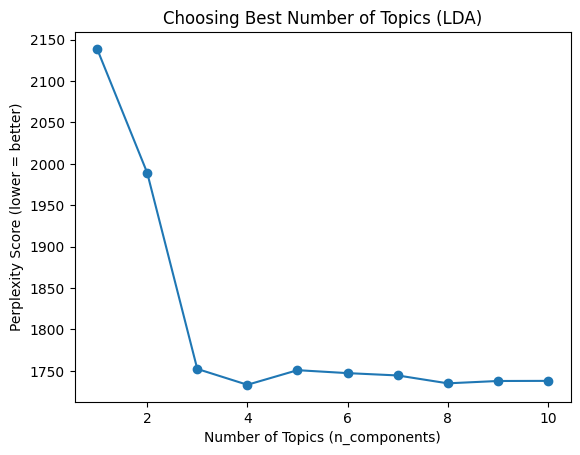

In [9]:
scores = []
topics = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

for n in topics:
    lda = LatentDirichletAllocation(n_components=n, random_state=42)
    lda.fit(X)
    score = lda.perplexity(X)
    scores.append(score)

plt.plot(topics, scores, marker='o')
plt.title("Choosing Best Number of Topics (LDA)")
plt.xlabel("Number of Topics (n_components)")
plt.ylabel("Perplexity Score (lower = better)")
plt.show()

##### Train the LDA model with 3 topics, then extract and display the top 10 most important words for each topic.

In [10]:
lda = LatentDirichletAllocation(n_components=4, random_state=42)
lda.fit(X)

words = vectorizer.get_feature_names_out()
num_words = 10

for i, topic in enumerate(lda.components_):
    top_words = [words[j] for j in topic.argsort()[-num_words:]]
    print(f"Topic {i+1}: {', '.join(top_words)}")

Topic 1: good, use, think, people, year, make, work, time, day, like
Topic 2: good, company, like, role, time, people, year, pay, work, job
Topic 3: action, contact, rule, report, moderator, message, question, subreddit, help, post
Topic 4: ask, day, need, manager, make, like, time, say, job, work


##### Get the topic probability distribution for each document in the dataset.

In [11]:
doc_topic_dist = lda.transform(X)

##### Assign each document to the topic with the highest probability.

In [12]:
data['topic_LDA'] = doc_topic_dist.argmax(axis=1)

##### Create and display a dictionary that assigns meaningful names to each LDA topic.

In [13]:
Topic_suggestion = {
    "Topic 1": "General Reflections on Work & Daily Life",
    "Topic 2": "Companies, Job Roles, Pay & Career Experience",
    "Topic 3": "Moderation, Rules & Platform Administration",
    "Topic 4": "Managers, Workplace Advice & Daily Job Issues",
}

print(Topic_suggestion)

{'Topic 1': 'General Reflections on Work & Daily Life', 'Topic 2': 'Companies, Job Roles, Pay & Career Experience', 'Topic 3': 'Moderation, Rules & Platform Administration', 'Topic 4': 'Managers, Workplace Advice & Daily Job Issues'}


In [14]:
topic_label_map = {i: Topic_suggestion[f"Topic {i+1}"] for i in range(4)}
data['topic_label_LDA'] = data['topic_LDA'].map(topic_label_map)

##### Let's group the data by topic and sentiment, then count how many records fall into each group.

In [15]:
sentiment_summary = (
    data.groupby(['topic_label_LDA', 'sentiment'])
      .size()
      .reset_index(name='count')
)
display(sentiment_summary)

,topic_label_LDA,sentiment,count
0,"Companies, Job Roles, Pay & Career Experience",Negative,1695
1,"Companies, Job Roles, Pay & Career Experience",Neutral,5334
2,"Companies, Job Roles, Pay & Career Experience",Positive,1241
3,General Reflections on Work & Daily Life,Negative,2957
4,General Reflections on Work & Daily Life,Neutral,6113
5,General Reflections on Work & Daily Life,Positive,1760
6,"Managers, Workplace Advice & Daily Job Issues",Negative,1995
7,"Managers, Workplace Advice & Daily Job Issues",Neutral,5275
8,"Managers, Workplace Advice & Daily Job Issues",Positive,1913
9,"Moderation, Rules & Platform Administration",Negative,8


##### Let draw a chat to show the relationship among the two of them

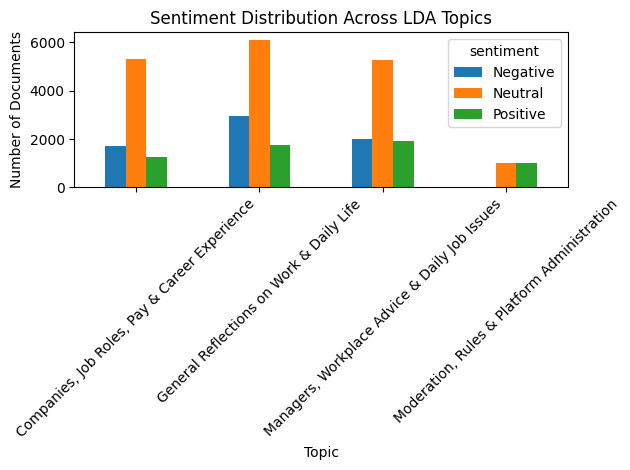

In [16]:
pivot_table = sentiment_summary.pivot(
    index='topic_label_LDA',
    columns='sentiment',
    values='count'
).fillna(0)

# Plot the bar chart
pivot_table.plot(kind='bar')

plt.title("Sentiment Distribution Across LDA Topics")
plt.xlabel("Topic")
plt.ylabel("Number of Documents")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##### **Create the Table**

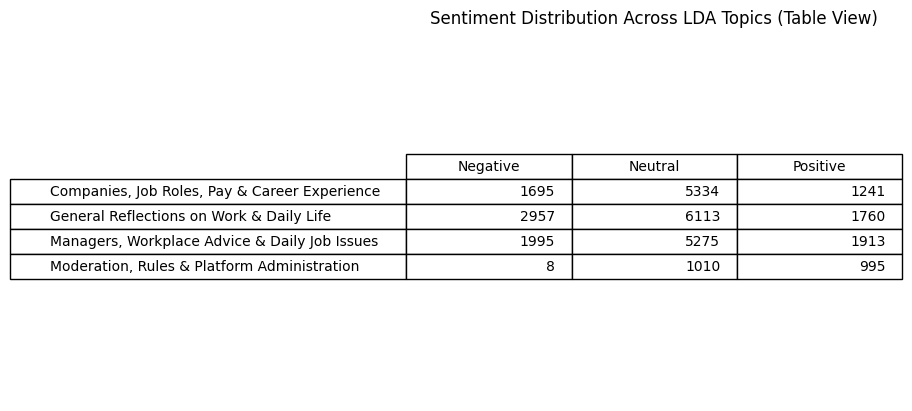

In [17]:
pivot_table = sentiment_summary.pivot(
    index='topic_label_LDA',
    columns='sentiment',
    values='count'
).fillna(0)

fig, ax = plt.subplots()
ax.axis('off')

table = ax.table(
    cellText=pivot_table.values,
    colLabels=pivot_table.columns,
    rowLabels=pivot_table.index,
    loc='center'
)

table.scale(1, 1.5)

plt.title("Sentiment Distribution Across LDA Topics (Table View)")
plt.show()

##### Let's build a Gensim LDA model and evaluate its topic quality using the coherence score.

In [18]:
corpus = [vectorizer.inverse_transform(x)[0] for x in X]
dictionary = Dictionary(corpus)

bow_corpus = [dictionary.doc2bow(doc) for doc in corpus]

lda_gensim = LdaModel(bow_corpus, num_topics=7, id2word=dictionary, passes=15, random_state=42)


coherence_model = CoherenceModel(model=lda_gensim, texts=corpus, dictionary=dictionary, coherence='c_v')
coherence_score = coherence_model.get_coherence()
print("Coherence Score:", coherence_score)

Coherence Score: 0.722740480382874


In [19]:
lda_json = {}

for _, row in sentiment_summary.iterrows():
    topic = row["topic_label_LDA"]
    sentiment = row["sentiment"]
    count = int(row["count"])

    if topic not in lda_json:
        lda_json[topic] = {}

    lda_json[topic][sentiment] = count


final_lda_json = {
    "LDA_Sentiment_Summary": lda_json
}
print(final_lda_json)

{'LDA_Sentiment_Summary': {'Companies, Job Roles, Pay & Career Experience': {'Negative': 1695, 'Neutral': 5334, 'Positive': 1241}, 'General Reflections on Work & Daily Life': {'Negative': 2957, 'Neutral': 6113, 'Positive': 1760}, 'Managers, Workplace Advice & Daily Job Issues': {'Negative': 1995, 'Neutral': 5275, 'Positive': 1913}, 'Moderation, Rules & Platform Administration': {'Negative': 8, 'Neutral': 1010, 'Positive': 995}}}


##### **Bertopic**

###### BERTopic is a topic modeling technique that uses BERT embeddings to generate coherent and meaningful topics from large text datasets.

##### Download the list of common stopwords used for text preprocessing

In [20]:
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

##### Let's removes automated moderator messages using predefined text patterns and keeps only genuine user-generated content for analysis.

In [21]:
patterns_to_remove = [
    "thank posting",
    "please help keep",
    "welcoming",
    "moderators",
    "megathread",
    "submissionpost",
    "automatically",
    "contact the moderators",
    "if you have a concern",
    "replying submissionpost",
    "help us make better",
]


def remove_auto_mod(text):
    for p in patterns_to_remove:
        if p in text.lower():
            return None
    return text

data["filtered_text"] = data["text_raw"].apply(remove_auto_mod)
data = data.dropna(subset=["filtered_text"])
documents = data["filtered_text"].tolist()

##### Let's converts the cleaned text column into a list of documents for further analysis.

In [22]:
documents = data["filtered_text"].tolist()

##### Let's set up and runs a customized BERTopic pipeline using Sentence-BERT embeddings, CountVectorizer, UMAP for dimensionality reduction, and HDBSCAN for clustering to generate well-separated, fine-grained topics from the text documents.

In [23]:
embedding_model = SentenceTransformer("all-mpnet-base-v2")

vectorizer_model = CountVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    min_df=10
)

#UMAP – more separation, more topics
umap_model = UMAP(
    n_neighbors=5,
    n_components=15,
    min_dist=0.0,
    random_state=42
)

# HDBSCAN – allow smaller clusters
hdbscan_model = HDBSCAN(
    min_cluster_size=80,
    min_samples=5,
    metric="euclidean",
    cluster_selection_method="eom",
    prediction_data=True
)

# BERTopic
topic_model = BERTopic(
    embedding_model=embedding_model,
    vectorizer_model=vectorizer_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    min_topic_size=10,
    nr_topics=None
)

topics, probs = topic_model.fit_transform(documents)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

##### Let retrieves a summary table of all discovered topics, including their sizes and labels.

In [24]:
topic_model.get_topic_info().head(10)

,Topic,Count,Name,Representation,Representative_Docs
0,-1,3876,-1_just_like_people_don,"[just, like, people, don, ve, time, think, wor...",[Throughout the course of my adult life I’ve r...
1,0,12493,0_job_work_time_ve,"[job, work, time, ve, don, just, company, like...",[Partner is losing her mind in her finance rol...
2,1,1946,1_presented_members_reading_2nd,"[presented, members, reading, 2nd, uk, private...","[""To catch a copper"" and ""24 hours in police c..."
3,2,834,2_noise_neighbours_police_neighbour,"[noise, neighbours, police, neighbour, door, j...",[Why is the consensus that asking upstairs nei...
4,3,589,3_food_chicken_meat_cheese,"[food, chicken, meat, cheese, cook, milk, eat,...",[Learn to handle chicken safely. It can be def...
5,4,490,4_card_money_delivery_number,"[card, money, delivery, number, bank, said, fl...",[The complete inability of couriers to deliver...
6,5,451,5_birthday_tomorrow_christmas_tonight,"[birthday, tomorrow, christmas, tonight, day, ...","[It's Late Thread [ 05 December 24 ] Thursday,..."
7,6,438,6_congratulations_hope_life_good,"[congratulations, hope, life, good, read, than...","[Dear Charlie,\n\nReading all of this… it is r..."
8,7,431,7_city_london_nice_live,"[city, london, nice, live, places, town, manch...","[Hi, I moved from Bournemouth to Birmingham ab..."
9,8,354,8_gas_energy_quote_materials,"[gas, energy, quote, materials, water, payment...",[How do you pay your workmen and have I been h...


##### Let extracts the top keywords for each topic and stores them in a dictionary for easy access and analysis.

In [25]:
topics_dict = topic_model.get_topics()

topic_words = {}

for topic_id, words in topics_dict.items():
    topic_words[topic_id] = [w for w, _ in words]

##### Let tokenizes each document by splitting it into a list of individual words.

In [26]:
texts = [doc.split() for doc in documents]

##### This line creates a Gensim dictionary that maps each unique word in the documents to a numerical ID.

In [27]:
dictionary = Dictionary(texts)

##### Let calculates the coherence score for each topic using only valid words from the dictionary, helping to evaluate how meaningful and consistent each topic is.

In [28]:
topic_coherence = {}

for topic_id, words_list in topic_words.items():
    filtered_words = [word for word in words_list if word in dictionary.token2id]

    if filtered_words:
        cm = CoherenceModel(
            topics=[filtered_words],
            texts=texts,
            dictionary=dictionary,
            coherence='c_v'
        )
        topic_coherence[topic_id] = cm.get_coherence()
    else:
        topic_coherence[topic_id] = None

##### Let's converts the topic coherence scores into a DataFrame, sorts them in descending order, and displays the top 15 most coherent topics.

In [29]:
df_coh = pd.DataFrame({
    "topic": list(topic_coherence.keys()),
    "coherence": list(topic_coherence.values())
})

df_coh_sorted = df_coh.sort_values("coherence", ascending=False)
df_coh_sorted.head(15)

,topic,coherence
21,20,0.777065
15,14,0.678941
16,15,0.625454
52,51,0.621519
44,43,0.617179
32,31,0.611209
19,18,0.609150
10,9,0.591266
23,22,0.577034
4,3,0.576592


##### Calculate overall coherence using the filtered topic words

In [30]:
filtered_global_topic_words = []
for topic_id, words_list in topic_words.items():
    filtered_words = [word for word in words_list if word in dictionary.token2id]
    if filtered_words:
        filtered_global_topic_words.append(filtered_words)
cm_global = CoherenceModel(
    topics=filtered_global_topic_words,
    texts=texts,
    dictionary=dictionary,
    coherence='c_v'
)

overall_coherence = cm_global.get_coherence()
print("Overall coherence:", overall_coherence)

Overall coherence: 0.4145440646742349


In [31]:
topic_model.get_topic_info().head(10)

,Topic,Count,Name,Representation,Representative_Docs
0,-1,3876,-1_just_like_people_don,"[just, like, people, don, ve, time, think, wor...",[Throughout the course of my adult life I’ve r...
1,0,12493,0_job_work_time_ve,"[job, work, time, ve, don, just, company, like...",[Partner is losing her mind in her finance rol...
2,1,1946,1_presented_members_reading_2nd,"[presented, members, reading, 2nd, uk, private...","[""To catch a copper"" and ""24 hours in police c..."
3,2,834,2_noise_neighbours_police_neighbour,"[noise, neighbours, police, neighbour, door, j...",[Why is the consensus that asking upstairs nei...
4,3,589,3_food_chicken_meat_cheese,"[food, chicken, meat, cheese, cook, milk, eat,...",[Learn to handle chicken safely. It can be def...
5,4,490,4_card_money_delivery_number,"[card, money, delivery, number, bank, said, fl...",[The complete inability of couriers to deliver...
6,5,451,5_birthday_tomorrow_christmas_tonight,"[birthday, tomorrow, christmas, tonight, day, ...","[It's Late Thread [ 05 December 24 ] Thursday,..."
7,6,438,6_congratulations_hope_life_good,"[congratulations, hope, life, good, read, than...","[Dear Charlie,\n\nReading all of this… it is r..."
8,7,431,7_city_london_nice_live,"[city, london, nice, live, places, town, manch...","[Hi, I moved from Bournemouth to Birmingham ab..."
9,8,354,8_gas_energy_quote_materials,"[gas, energy, quote, materials, water, payment...",[How do you pay your workmen and have I been h...


##### This code assigns meaningful, human-readable labels to selected topics to improve the interpretability of the BERTopic model results.

In [32]:
topic_labels = {
    -1: "General Work & Life Discussion",
    0: "UK Politics, Labour, Government & Tax Policy",
    1: "Jobs, Experience, Careers & Employability",
    2: "UK Cities, London & Places to Live",
    3: "Life, Friendships & Personal Reflection",
    4: "Support, Congratulations & Positive Messages",
    5: "Managers, Teams & Workplace Relationships",
    6: "Sickness, Health, GP Notes & Time Off Work",
    7: "Zero-Hours Contracts, Shifts & Overtime",
    8: "Living in London, Rent & Relocation"
}

topic_model.set_topic_labels(topic_labels)

###### This displays the top 10 topics along with their updated labels, sizes, and key information after topic labeling.

In [33]:
topic_model.get_topic_info().head(10)

,Topic,Count,Name,CustomName,Representation,Representative_Docs
0,-1,3876,-1_just_like_people_don,General Work & Life Discussion,"[just, like, people, don, ve, time, think, wor...",[Throughout the course of my adult life I’ve r...
1,0,12493,0_job_work_time_ve,"UK Politics, Labour, Government & Tax Policy","[job, work, time, ve, don, just, company, like...",[Partner is losing her mind in her finance rol...
2,1,1946,1_presented_members_reading_2nd,"Jobs, Experience, Careers & Employability","[presented, members, reading, 2nd, uk, private...","[""To catch a copper"" and ""24 hours in police c..."
3,2,834,2_noise_neighbours_police_neighbour,"UK Cities, London & Places to Live","[noise, neighbours, police, neighbour, door, j...",[Why is the consensus that asking upstairs nei...
4,3,589,3_food_chicken_meat_cheese,"Life, Friendships & Personal Reflection","[food, chicken, meat, cheese, cook, milk, eat,...",[Learn to handle chicken safely. It can be def...
5,4,490,4_card_money_delivery_number,"Support, Congratulations & Positive Messages","[card, money, delivery, number, bank, said, fl...",[The complete inability of couriers to deliver...
6,5,451,5_birthday_tomorrow_christmas_tonight,"Managers, Teams & Workplace Relationships","[birthday, tomorrow, christmas, tonight, day, ...","[It's Late Thread [ 05 December 24 ] Thursday,..."
7,6,438,6_congratulations_hope_life_good,"Sickness, Health, GP Notes & Time Off Work","[congratulations, hope, life, good, read, than...","[Dear Charlie,\n\nReading all of this… it is r..."
8,7,431,7_city_london_nice_live,"Zero-Hours Contracts, Shifts & Overtime","[city, london, nice, live, places, town, manch...","[Hi, I moved from Bournemouth to Birmingham ab..."
9,8,354,8_gas_energy_quote_materials,"Living in London, Rent & Relocation","[gas, energy, quote, materials, water, payment...",[How do you pay your workmen and have I been h...


##### Merging the topic with sentiment and drawing a chart

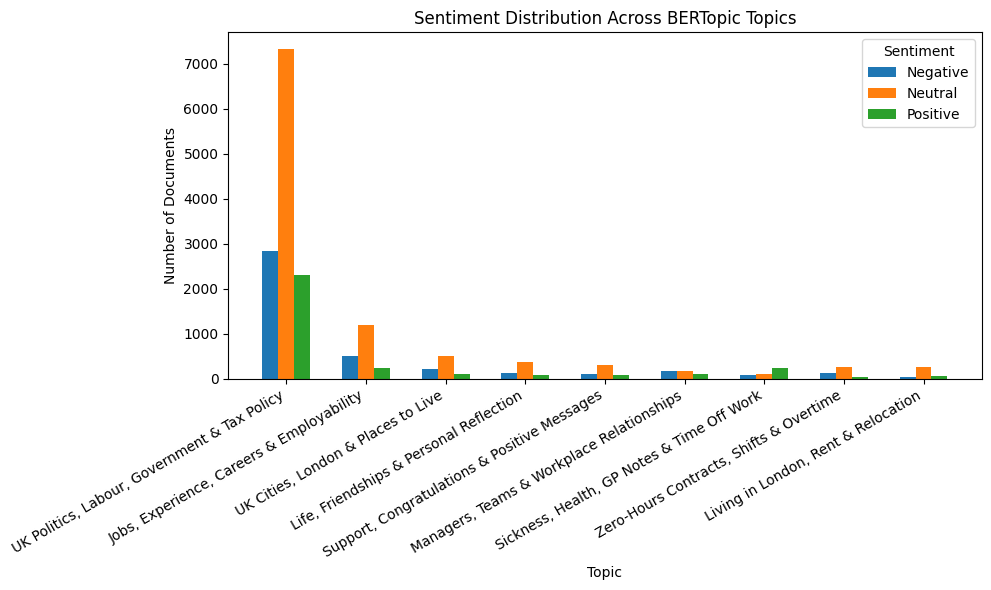

In [34]:
data = data.reset_index(drop=True)

data["topic_id"] = topics
data["topic_label"] = data["topic_id"].map(topic_labels)

data_plot = data[data["topic_id"] != -1].copy()

sent_counts = (
    data_plot.groupby(["topic_label", "sentiment"])
             .size()
             .reset_index(name="count")
)

sent_pivot = sent_counts.pivot(
    index="topic_label",
    columns="sentiment",
    values="count"
).fillna(0)

topic_order_df = (
    data_plot[["topic_id", "topic_label"]]
    .drop_duplicates()
    .sort_values("topic_id")
)

topic_order_df = topic_order_df.dropna(subset=['topic_label'])
sent_pivot = sent_pivot.loc[topic_order_df["topic_label"]]

topics_list = sent_pivot.index.tolist()
sentiments = sent_pivot.columns.tolist()

x = np.arange(len(topics_list))
width = 0.2

fig, ax = plt.subplots(figsize=(10, 6))

for i, s in enumerate(sentiments):
    ax.bar(
        x + (i - (len(sentiments)-1)/2) * width,
        sent_pivot[s].values,
        width,
        label=s
    )

ax.set_xticks(x)
ax.set_xticklabels(topics_list, rotation=30, ha="right")
ax.set_ylabel("Number of Documents")
ax.set_xlabel("Topic")
ax.set_title("Sentiment Distribution Across BERTopic Topics")
ax.legend(title="Sentiment")

plt.tight_layout()
plt.show()

##### Creating a JSON File to get the topic

In [35]:
bertopic_json = {}

for topic_id, words in topic_words.items():

    if topic_id not in data["topic_id"].values:
        continue
    topic_name = topic_labels.get(topic_id, f"Topic {topic_id}")
    doc_count = int((data["topic_id"] == topic_id).sum())
    coherence_score = topic_coherence.get(topic_id)
    sentiment_dist = (
        data[data["topic_id"] == topic_id]["sentiment"]
        .value_counts()
        .to_dict()
    )
    bertopic_json[f"topic_{topic_id}"] = {
        "topic_id": int(topic_id),
        "topic_label": topic_name,
        "top_words": words[:10],
        "document_count": doc_count,
        "coherence_score": coherence_score,
        "sentiment_distribution": sentiment_dist
    }

final_json = {
    "Bertopic": bertopic_json
}

print(final_json)

{'Bertopic': {'topic_-1': {'topic_id': -1, 'topic_label': 'General Work & Life Discussion', 'top_words': ['just', 'like', 'people', 'don', 've', 'time', 'think', 'work', 'got', 'way'], 'document_count': 3876, 'coherence_score': np.float64(0.29041271910046945), 'sentiment_distribution': {'Neutral': 2399, 'Negative': 859, 'Positive': 618}}, 'topic_0': {'topic_id': 0, 'topic_label': 'UK Politics, Labour, Government & Tax Policy', 'top_words': ['job', 'work', 'time', 've', 'don', 'just', 'company', 'like', 'role', 'jobs'], 'document_count': 12493, 'coherence_score': np.float64(0.2971003461508183), 'sentiment_distribution': {'Neutral': 7336, 'Negative': 2850, 'Positive': 2307}}, 'topic_1': {'topic_id': 1, 'topic_label': 'Jobs, Experience, Careers & Employability', 'top_words': ['presented', 'members', 'reading', '2nd', 'uk', 'private', 'government', 'https', 'people', 'tax'], 'document_count': 1946, 'coherence_score': np.float64(0.38905442622850395), 'sentiment_distribution': {'Neutral': 11

##### Collapse Both LDA and Bertopic result for later exploration

In [36]:
data_final =  {
    "2024": {
        "LDA": final_lda_json,
        "Bertopic": final_json
    }
}

print(data_final)

{'2024': {'LDA': {'LDA_Sentiment_Summary': {'Companies, Job Roles, Pay & Career Experience': {'Negative': 1695, 'Neutral': 5334, 'Positive': 1241}, 'General Reflections on Work & Daily Life': {'Negative': 2957, 'Neutral': 6113, 'Positive': 1760}, 'Managers, Workplace Advice & Daily Job Issues': {'Negative': 1995, 'Neutral': 5275, 'Positive': 1913}, 'Moderation, Rules & Platform Administration': {'Negative': 8, 'Neutral': 1010, 'Positive': 995}}}, 'Bertopic': {'Bertopic': {'topic_-1': {'topic_id': -1, 'topic_label': 'General Work & Life Discussion', 'top_words': ['just', 'like', 'people', 'don', 've', 'time', 'think', 'work', 'got', 'way'], 'document_count': 3876, 'coherence_score': np.float64(0.29041271910046945), 'sentiment_distribution': {'Neutral': 2399, 'Negative': 859, 'Positive': 618}}, 'topic_0': {'topic_id': 0, 'topic_label': 'UK Politics, Labour, Government & Tax Policy', 'top_words': ['job', 'work', 'time', 've', 'don', 'just', 'company', 'like', 'role', 'jobs'], 'document_co

In [37]:
with open("2024_topic_model_master.json", "w", encoding="utf-8") as f:
    json.dump(data_final, f, indent=4, ensure_ascii=False)

print("Master JSON saved as topic_model_master.json")

Master JSON saved as topic_model_master.json
